# Auto Parts Demand Forecasting — Baseline + LightGBM Blend Improved

Notebook này được chỉnh thêm chế độ **LightGBM correction ratio**:

1. Giữ baseline chính theo cấu hình đang cho Kaggle tốt hơn: **14 / 28 / 56 / 90**.
2. Sửa lỗi `recency_rules` bị ghi đè sai thứ tự.
3. Thêm rolling validation theo **28 ngày** để sát Public/Private leaderboard hơn.
4. Tune alpha ở vùng nhỏ thay vì chỉ thử `0.1 → 0.9`.
5. Thêm blend theo **profit rank** và **forecast horizon**.
6. Thêm optional baseline ensemble: fast / stable / long.
7. Thêm helper gợi ý rule riêng cho top contribution SKU, mặc định không tự apply.

> Phần LightGBM vẫn predict `Quantity/demand_qty` trực tiếp. Notebook này **chưa áp dụng ratio/residual correction**.

**Bản này thêm `LGBM_TARGET_MODE = "ratio"`: LightGBM học hệ số chỉnh baseline thay vì dự đoán Quantity trực tiếp.**


# PHẦN 1 — Setup & đọc dữ liệu

Phần này:
- Import thư viện.
- Khai báo đường dẫn.
- Bật/tắt LightGBM.
- Đọc và làm sạch `train.csv`.

In [1]:
import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

RANDOM_STATE = 42
EPS = 1e-9

# =========================
# CONFIG
# =========================
def resolve_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "main" / "data" / "train.csv").exists():
            return p
        if (p / "data" / "train.csv").exists():
            return p
    raise FileNotFoundError(
        "Không tìm thấy main/data/train.csv. Mở notebook từ main/src/ hoặc chạy Jupyter tại root repo."
    )


def resolve_data_dir(repo_root: Path) -> Path:
    main_data = repo_root / "main" / "data"
    if (main_data / "train.csv").exists():
        return main_data
    return repo_root / "data"


REPO_ROOT = resolve_repo_root()
DATA_DIR = resolve_data_dir(REPO_ROOT)
MAIN_DIR = REPO_ROOT / "main" if (REPO_ROOT / "main").is_dir() else REPO_ROOT
OUTPUT_DIR = MAIN_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

# Fallback Colab / mount tạm
if not TRAIN_PATH.exists() and Path("/mnt/data/train.csv").exists():
    TRAIN_PATH = Path("/mnt/data/train.csv")
if not SAMPLE_PATH.exists() and Path("/mnt/data/sample_submission.csv").exists():
    SAMPLE_PATH = Path("/mnt/data/sample_submission.csv")

# LightGBM có thể mất thời gian. Nếu máy yếu, để False trước để chạy baseline.
RUN_LIGHTGBM = True
RUN_LIGHTGBM_ROLLING = True
TOP_N_SKUS = 2892

# LightGBM target mode:
# - "quantity": giống bản cũ, model dự đoán trực tiếp Quantity.
# - "ratio": model học correction ratio = actual / baseline_ref, sau đó quy về Quantity.
LGBM_TARGET_MODE = "ratio"
RATIO_EPS = 0.10
RATIO_CLIP_MAX = 2.5
# Ratio target: log1p(ratio) thay vì clip — phân phối đều hơn, giảm outlier.
RATIO_USE_LOG_TARGET = True
RATIO_PRED_LAGS = [1, 7, 14]

# Bản Kaggle tốt nhất hiện tại của bạn đang hợp với baseline ổn định này.
BASELINE_WINDOWS = (14, 28, 56, 90)
BASELINE_WEIGHTS = (0.40, 0.30, 0.20, 0.10)
SUNDAY_FACTOR_FLOOR = 0.001

# Validation nên dùng 28 ngày vì Public/Private leaderboard đều là 28 ngày.
VALIDATION_HORIZON = 28
N_ROLLING_FOLDS = 3
ROLLING_STEP_DAYS = 28

# Optional: ensemble nhiều baseline. Mặc định False để giữ bản stable đang tốt.
# Sau khi chạy validation, có thể bật True để thử baseline_fast/stable/long.
USE_BASELINE_ENSEMBLE = False
BASELINE_ENSEMBLE_CONFIGS = [
    {
        "name": "fast",
        "windows": (7, 14, 28, 56),
        "weights": (0.30, 0.35, 0.25, 0.10),
        "ensemble_weight": 0.20,
    },
    {
        "name": "stable",
        "windows": (14, 28, 56, 90),
        "weights": (0.40, 0.30, 0.20, 0.10),
        "ensemble_weight": 0.60,
    },
    {
        "name": "long",
        "windows": (28, 56, 90, 180),
        "weights": (0.35, 0.30, 0.20, 0.15),
        "ensemble_weight": 0.20,
    },
]

# Constant-alpha grid nếu muốn dùng blend đơn giản.
ALPHA_GRID = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00]

# Rank/horizon alpha: cho LightGBM can thiệp mạnh hơn ở SKU quan trọng và horizon gần.
USE_RANK_HORIZON_ALPHA = False
ALPHA_SCALE_GRID = [0.50, 0.75, 1.00, 1.25, 1.50]
RANK_ALPHA_CONFIG = {
    "top_213": 0.12,
    "rank_214_1403": 0.08,
    "rank_1404_2000": 0.04,
    "tail": 0.00,
}
HORIZON_ALPHA_CONFIG = {
    "h_1_7": 1.20,
    "h_8_14": 1.00,
    "h_15_28": 0.80,
    "h_29_56": 0.50,
}

# Optional rule thủ công cho top contribution SKU. Mặc định không apply để tránh overfit.
USE_SPECIAL_SKU_MULTIPLIER = False
SPECIAL_SKU_MULTIPLIER = {
    # Ví dụ sau khi xem rolling validation:
    # "SKU-14323": 1.10,
    # "SKU-10532": 0.85,
}

print("TRAIN_PATH:", TRAIN_PATH, "| exists:", TRAIN_PATH.exists())
print("SAMPLE_PATH:", SAMPLE_PATH, "| exists:", SAMPLE_PATH.exists())
print("Baseline:", BASELINE_WINDOWS, BASELINE_WEIGHTS)
print("TOP_N_SKUS:", TOP_N_SKUS, "| VALIDATION_HORIZON:", VALIDATION_HORIZON)
print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR, "| exists:", DATA_DIR.exists())
print("TRAIN_PATH:", TRAIN_PATH, "| exists:", TRAIN_PATH.exists())
print("SAMPLE_PATH:", SAMPLE_PATH, "| exists:", SAMPLE_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)
print("LGBM_TARGET_MODE:", LGBM_TARGET_MODE)

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
    print("LightGBM is available.")
except Exception as e:
    HAS_LIGHTGBM = False
    print("LightGBM is NOT available.")
    print("Nếu muốn chạy LightGBM, cài bằng: pip install lightgbm")


TRAIN_PATH: c:\Homework\Code File\Python Code File\giải cỏ\main\data\train.csv | exists: True
SAMPLE_PATH: c:\Homework\Code File\Python Code File\giải cỏ\main\data\sample_submission.csv | exists: True
Baseline: (14, 28, 56, 90) (0.4, 0.3, 0.2, 0.1)
TOP_N_SKUS: 2892 | VALIDATION_HORIZON: 28
REPO_ROOT: c:\Homework\Code File\Python Code File\giải cỏ\main
DATA_DIR: c:\Homework\Code File\Python Code File\giải cỏ\main\data | exists: True
TRAIN_PATH: c:\Homework\Code File\Python Code File\giải cỏ\main\data\train.csv | exists: True
SAMPLE_PATH: c:\Homework\Code File\Python Code File\giải cỏ\main\data\sample_submission.csv | exists: True
OUTPUT_DIR: c:\Homework\Code File\Python Code File\giải cỏ\main\output
LGBM_TARGET_MODE: ratio
LightGBM is available.


## Patch P1/P2

- **P1**: `baseline_ref` trong LightGBM ratio mode được đổi từ raw rolling baseline sang `raw rolling baseline × weekday_factor`, để khớp với baseline dùng lúc inference. Đồng thời future feature cũng dùng cùng định nghĩa này.
- **P2**: `LAG_FEATURES` được mở rộng từ `[1, 2, 3, 7, 14, 28, 56]` sang `[1, 2, 3, 7, 14, 28, 56, 91, 182, 364, 365]`.


In [2]:
df = pd.read_csv(TRAIN_PATH)
print("Raw shape:", df.shape)
display(df.head())
display(df.dtypes)

Raw shape: (711980, 8)


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000


Date           object
Stt            object
ItemCode       object
Quantity        int64
UnitPrice      object
SalesAmount     int64
Unit Cost      object
Cost Amount    object
dtype: object

In [3]:
def parse_vn_number(s):
    """
    Chuyển cột số/tiền về numeric an toàn.
    Xử lý được:
    - số đã là int/float
    - chuỗi dùng dấu phẩy thập phân: '123559,1'
    - chuỗi có dấu cách
    """
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    x = (
        s.astype(str)
         .str.strip()
         .str.replace(" ", "", regex=False)
         .str.replace(".", "", regex=False)   # phòng trường hợp có dấu ngăn cách nghìn
         .str.replace(",", ".", regex=False)  # đổi dấu phẩy thập phân
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    return pd.to_numeric(x, errors="coerce")


# Chuẩn hóa tên cột
df["Date"] = pd.to_datetime(df["Date"])

df = df.rename(columns={
    "Unit Cost": "UnitCost",
    "Cost Amount": "CostAmount"
})

required_cols = ["Date", "Stt", "ItemCode", "Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]
missing_cols = [c for c in required_cols if c not in df.columns]
assert len(missing_cols) == 0, f"Missing columns: {missing_cols}"

# Ép kiểu số
for col in ["Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]:
    df[col] = parse_vn_number(df[col])

print("Missing after parse:")
display(df[["Quantity", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount"]].isna().sum().to_frame("missing_after_parse"))

# Feature nghiệp vụ
df["line_profit"] = df["SalesAmount"] - df["CostAmount"]

# Target demand không âm
# Quantity âm có thể là bảo hành, đổi miễn phí, hàng tặng, chuyển kho, hao hụt...
df["demand_qty"] = df["Quantity"].clip(lower=0)

# Flag EDA
df["is_negative_qty"] = df["Quantity"] < 0
df["is_positive_qty"] = df["Quantity"] > 0
df["is_zero_revenue"] = df["SalesAmount"] == 0
df["is_negative_revenue"] = df["SalesAmount"] < 0
df["is_negative_cost"] = df["CostAmount"] < 0

print("Clean shape:", df.shape)
display(df.head())
display(df.dtypes)

Missing after parse:


,missing_after_parse
Quantity,0
UnitPrice,0
SalesAmount,0
UnitCost,0
CostAmount,0


Clean shape: (711980, 15)


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,UnitCost,CostAmount,line_profit,demand_qty,is_negative_qty,is_positive_qty,is_zero_revenue,is_negative_revenue,is_negative_cost
0,2020-11-17,2000004,SKU-08063,12,"242,700.000000",2184300,"123,559.100000","1,482,709.000000","701,591.000000",12,False,True,False,False,False
1,2020-11-17,2000003,SKU-09458,600,"131,818.181800",79090909,"110,000.000000","66,000,000.000000","13,090,909.000000",600,False,True,False,False,False
2,2020-11-18,2000007,SKU-08062,6,"230,000.000000",940909,"101,000.000000","606,000.000000","334,909.000000",6,False,True,False,False,False
3,2020-11-18,2000006,SKU-09458,240,"270,000.000000",44181818,"110,000.000000","26,400,000.000000","17,781,818.000000",240,False,True,False,False,False
4,2020-11-18,2000005,SKU-09458,240,"270,000.000000",44181818,"110,000.000000","26,400,000.000000","17,781,818.000000",240,False,True,False,False,False


Date                   datetime64[ns]
Stt                            object
ItemCode                       object
Quantity                        int64
UnitPrice                     float64
SalesAmount                     int64
UnitCost                      float64
CostAmount                    float64
line_profit                   float64
demand_qty                      int64
is_negative_qty                  bool
is_positive_qty                  bool
is_zero_revenue                  bool
is_negative_revenue              bool
is_negative_cost                 bool
dtype: object

# PHẦN 2 — EDA nhanh & hiểu bài toán

Phần này kiểm tra:
- Số dòng, số SKU, khoảng ngày.
- Dữ liệu âm.
- Độ thưa SKU-ngày.
- Weekday effect.

In [4]:
overview = {
    "n_rows": len(df),
    "n_skus": df["ItemCode"].nunique(),
    "min_date": df["Date"].min(),
    "max_date": df["Date"].max(),
    "n_transaction_dates": df["Date"].nunique(),
    "calendar_days": (df["Date"].max() - df["Date"].min()).days + 1,
    "total_quantity_net": df["Quantity"].sum(),
    "total_demand_qty_positive_only": df["demand_qty"].sum(),
    "total_negative_quantity": df.loc[df["Quantity"] < 0, "Quantity"].sum(),
    "n_negative_qty_rows": int((df["Quantity"] < 0).sum()),
    "n_positive_qty_rows": int((df["Quantity"] > 0).sum()),
}
display(pd.Series(overview).to_frame("value"))

print("Duplicate rows:", df.duplicated().sum())

num_cols = ["Quantity", "demand_qty", "UnitPrice", "SalesAmount", "UnitCost", "CostAmount", "line_profit"]
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

,value
n_rows,711980
n_skus,15972
min_date,2020-11-17 00:00:00
max_date,2025-09-05 00:00:00
n_transaction_dates,1411
calendar_days,1754
total_quantity_net,2447253
total_demand_qty_positive_only,2534091
total_negative_quantity,-86838
n_negative_qty_rows,37434


Duplicate rows: 1473


,count,mean,std,min,1%,5%,50%,95%,99%,max
Quantity,"711,980.000000",3.437250,25.490722,-998.000000,-2.000000,-1.000000,1.000000,10.000000,30.000000,"5,998.000000"
demand_qty,"711,980.000000",3.559217,25.305183,0.000000,0.000000,0.000000,1.000000,10.000000,30.000000,"5,998.000000"
UnitPrice,"711,980.000000","536,172.655003","1,151,269.375674","-30,011,000.000000","-1,200,000.000000","-68,600.000000","285,000.000000","1,750,000.000000","3,450,000.000000","79,627,535.000000"
SalesAmount,"711,980.000000","970,936.600739","3,888,066.625386","-184,240,000.000000","-1,420,000.000000","-110,000.000000","510,000.000000","2,805,000.000000","7,968,000.000000","932,413,092.000000"
UnitCost,"711,980.000000","377,920.829574","665,555.066369","-19,799,019.370000","-893,717.655500","-40,000.000000","202,277.600000","1,334,680.062000","2,464,848.400700","40,500,000.000000"
CostAmount,"711,980.000000","733,517.480438","3,282,585.739951","-166,865,193.000000","-1,100,000.000000","-65,287.550000","366,139.000000","2,187,666.000000","6,057,758.410000","838,717,832.000000"
line_profit,"711,980.000000","237,419.120301","1,181,891.727748","-72,895,386.000000","-596,061.240000","-110,889.450000","125,972.000000","800,791.450000","2,005,899.080000","133,193,972.000000"


In [5]:
neg = df[df["Quantity"] < 0].copy()

neg_patterns = pd.DataFrame({
    "condition": [
        "Quantity < 0",
        "Quantity < 0 & SalesAmount < 0 & CostAmount < 0",
        "Quantity < 0 & SalesAmount == 0",
        "Quantity < 0 & SalesAmount < 0",
        "Quantity < 0 & CostAmount < 0",
        "Quantity < 0 & line_profit <= 0",
        "Quantity < 0 & line_profit > 0",
    ],
    "n_rows": [
        (df["Quantity"] < 0).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] < 0) & (df["CostAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] == 0)).sum(),
        ((df["Quantity"] < 0) & (df["SalesAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["CostAmount"] < 0)).sum(),
        ((df["Quantity"] < 0) & (df["line_profit"] <= 0)).sum(),
        ((df["Quantity"] < 0) & (df["line_profit"] > 0)).sum(),
    ]
})
display(neg_patterns)

neg_sku = (
    neg.groupby("ItemCode")
       .agg(
           neg_rows=("Quantity", "size"),
           neg_qty=("Quantity", "sum"),
           neg_sales=("SalesAmount", "sum"),
           neg_cost=("CostAmount", "sum"),
           neg_profit=("line_profit", "sum")
       )
       .sort_values("neg_rows", ascending=False)
)
display(neg_sku.head(20))

,condition,n_rows
0,Quantity < 0,37434
1,Quantity < 0 & SalesAmount < 0 & CostAmount < 0,37279
2,Quantity < 0 & SalesAmount == 0,119
3,Quantity < 0 & SalesAmount < 0,37315
4,Quantity < 0 & CostAmount < 0,37393
5,Quantity < 0 & line_profit <= 0,36137
6,Quantity < 0 & line_profit > 0,1297


,neg_rows,neg_qty,neg_sales,neg_cost,neg_profit
ItemCode,,,,,
SKU-15599,97,-229,-32898820,"-23,499,154.510000","-9,399,665.490000"
SKU-15146,96,-184,-29871220,"-21,255,992.080000","-8,615,227.920000"
SKU-14323,94,-265,-65620464,"-50,066,803.500000","-15,553,660.500000"
SKU-00324,87,-90,-115109296,"-89,257,481.000000","-25,851,815.000000"
SKU-15145,86,-268,-32686755,"-22,890,808.690000","-9,795,946.310000"
SKU-14806,81,-148,-31896315,"-23,818,482.600000","-8,077,832.400000"
SKU-14320,78,-195,-46193432,"-33,167,697.590000","-13,025,734.410000"
SKU-12064,77,-133,-128329222,"-65,156,458.120000","-63,172,763.880000"
SKU-09510,77,-377,-41492724,"-31,638,754.090000","-9,853,969.910000"


In [6]:
# Aggregate transaction line -> SKU-day
daily = (
    df.groupby(["ItemCode", "Date"], as_index=False)
      .agg(
          y=("demand_qty", "sum"),
          net_qty=("Quantity", "sum"),
          sales=("SalesAmount", "sum"),
          cost=("CostAmount", "sum"),
          profit=("line_profit", "sum"),
          n_lines=("Stt", "size")
      )
)

daily["is_positive_day"] = daily["y"] > 0

n_skus = df["ItemCode"].nunique()
all_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
n_calendar_days = len(all_dates)

possible_sku_days = n_skus * n_calendar_days
observed_sku_days = daily[["ItemCode", "Date"]].drop_duplicates().shape[0]
positive_sku_days = daily.loc[daily["y"] > 0, ["ItemCode", "Date"]].drop_duplicates().shape[0]

density_info = {
    "n_skus": n_skus,
    "n_calendar_days": n_calendar_days,
    "possible_sku_days": possible_sku_days,
    "observed_sku_days_in_transactions": observed_sku_days,
    "positive_sku_days": positive_sku_days,
    "positive_density": positive_sku_days / possible_sku_days,
}
display(pd.Series(density_info).to_frame("value"))
display(daily.head())

,value
n_skus,"15,972.000000"
n_calendar_days,"1,754.000000"
possible_sku_days,"28,014,888.000000"
observed_sku_days_in_transactions,"507,050.000000"
positive_sku_days,"485,454.000000"
positive_density,0.017328


,ItemCode,Date,y,net_qty,sales,cost,profit,n_lines,is_positive_day
0,SKU-00001,2025-05-26,1,1,830368,0.000000,"830,368.000000",1,True
1,SKU-00001,2025-05-27,1,1,1032840,0.000000,"1,032,840.000000",1,True
2,SKU-00001,2025-05-28,2,2,2084484,0.000000,"2,084,484.000000",2,True
3,SKU-00001,2025-05-30,2,2,1414600,0.000000,"1,414,600.000000",2,True
4,SKU-00001,2025-06-04,6,6,4138320,0.000000,"4,138,320.000000",6,True


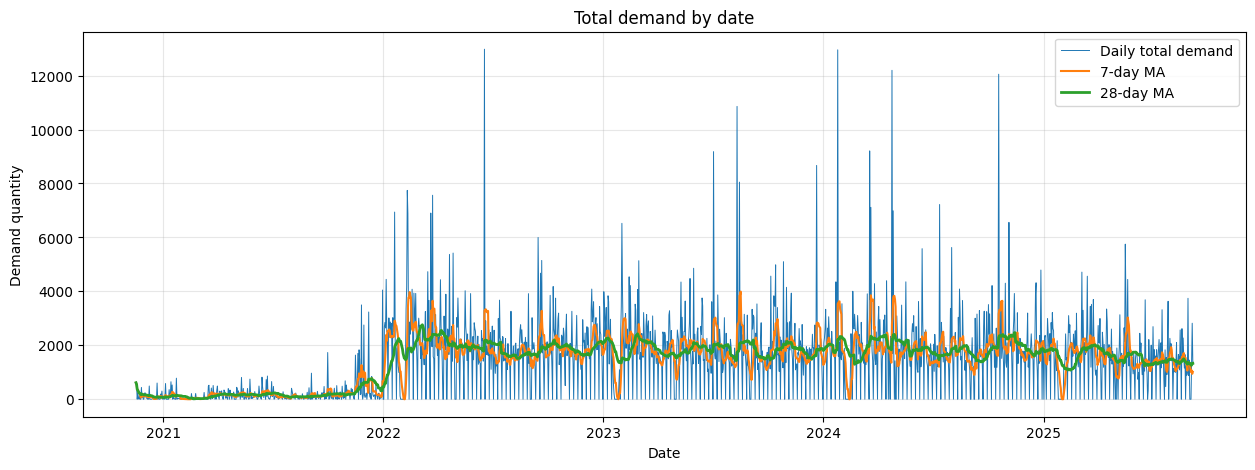

,mean_y,median_y,max_y,mean_active_skus,n_days
day_name,,,,,
Monday,"1,816.712000","1,866.500000","9,208.000000",371.360000,250
Tuesday,"1,688.171315","1,727.000000","8,050.000000",351.513944,251
Wednesday,"1,769.378486","1,686.000000","12,196.000000",338.119522,251
Thursday,"1,777.840637","1,698.000000","12,956.000000",330.697211,251
Friday,"1,764.944223","1,660.000000","12,051.000000",331.171315,251
Saturday,"1,289.036000","1,395.500000","12,979.000000",299.860000,250
Sunday,2.280000,0.000000,506.000000,0.072000,250


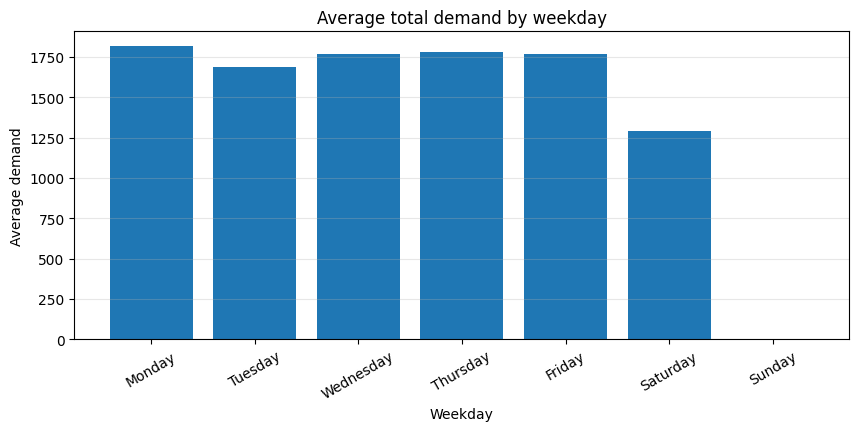

In [7]:
daily_total = (
    daily.groupby("Date", as_index=False)
         .agg(
             total_y=("y", "sum"),
             total_net_qty=("net_qty", "sum"),
             total_sales=("sales", "sum"),
             total_profit=("profit", "sum"),
             active_skus=("ItemCode", "nunique"),
             n_lines=("n_lines", "sum")
         )
)

daily_total = (
    pd.DataFrame({"Date": all_dates})
    .merge(daily_total, on="Date", how="left")
    .fillna({
        "total_y": 0,
        "total_net_qty": 0,
        "total_sales": 0,
        "total_profit": 0,
        "active_skus": 0,
        "n_lines": 0
    })
)

daily_total["dow"] = daily_total["Date"].dt.dayofweek
daily_total["day_name"] = daily_total["Date"].dt.day_name()
daily_total["month"] = daily_total["Date"].dt.month
daily_total["year"] = daily_total["Date"].dt.year
daily_total["y_7d_ma"] = daily_total["total_y"].rolling(7, min_periods=1).mean()
daily_total["y_28d_ma"] = daily_total["total_y"].rolling(28, min_periods=1).mean()

plt.figure(figsize=(15, 5))
plt.plot(daily_total["Date"], daily_total["total_y"], linewidth=0.7, label="Daily total demand")
plt.plot(daily_total["Date"], daily_total["y_7d_ma"], linewidth=1.5, label="7-day MA")
plt.plot(daily_total["Date"], daily_total["y_28d_ma"], linewidth=2, label="28-day MA")
plt.title("Total demand by date")
plt.xlabel("Date")
plt.ylabel("Demand quantity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_stats = (
    daily_total.groupby("day_name")
    .agg(
        mean_y=("total_y", "mean"),
        median_y=("total_y", "median"),
        max_y=("total_y", "max"),
        mean_active_skus=("active_skus", "mean"),
        n_days=("Date", "size")
    )
    .reindex(weekday_order)
)
display(weekday_stats)

plt.figure(figsize=(10, 4))
plt.bar(weekday_stats.index, weekday_stats["mean_y"])
plt.title("Average total demand by weekday")
plt.xlabel("Weekday")
plt.ylabel("Average demand")
plt.xticks(rotation=30)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# PHẦN 3 — Metric WRMSSE, profit weight & validation functions

Phần này tạo các hàm dùng xuyên suốt notebook:
- Aggregate daily demand.
- Tính profit weight.
- Tính scale RMSSE.
- Tính WRMSSE.
- Tạo actual validation matrix.

In [8]:
def aggregate_daily_y(transactions, value_col="demand_qty"):
    return (
        transactions.groupby(["ItemCode", "Date"], as_index=False)[value_col]
        .sum()
        .rename(columns={value_col: "y"})
    )


def compute_sku_weights(transactions):
    tmp = transactions.copy()
    if "line_profit" not in tmp.columns:
        tmp["line_profit"] = tmp["SalesAmount"] - tmp["CostAmount"]

    w = (
        tmp.groupby("ItemCode")["line_profit"]
           .sum()
           .rename("profit")
           .reset_index()
    )
    w["profit_pos"] = w["profit"].clip(lower=0)
    total = w["profit_pos"].sum()
    w["weight"] = np.where(total > 0, w["profit_pos"] / total, 0)
    return w[["ItemCode", "profit", "profit_pos", "weight"]]


def compute_rmsse_scale(train_daily_sparse, sku_list, train_dates):
    date_to_idx = pd.Series(np.arange(len(train_dates)), index=train_dates)
    grouped = dict(tuple(train_daily_sparse.groupby("ItemCode")))
    result = []

    for sku in sku_list:
        arr = np.zeros(len(train_dates), dtype=np.float32)
        if sku in grouped:
            g = grouped[sku]
            idx = date_to_idx.loc[g["Date"]].to_numpy()
            arr[idx] = g["y"].to_numpy(dtype=np.float32)

        if len(arr) <= 1:
            scale = EPS
        else:
            diffs = np.diff(arr)
            scale = float(np.mean(diffs ** 2))
            if scale <= 0:
                scale = EPS
        result.append((sku, scale))

    return pd.DataFrame(result, columns=["ItemCode", "scale"])


def make_actual_matrix_long(daily_sparse, sku_list, dates, value_col="y"):
    idx = pd.MultiIndex.from_product([sku_list, dates], names=["ItemCode", "Date"])
    s = daily_sparse.set_index(["ItemCode", "Date"])[value_col]
    out = s.reindex(idx, fill_value=0).reset_index()
    out = out.rename(columns={value_col: "actual"})
    return out


def wrmsse_score(actual_long, pred_long, scale_df, weight_df):
    eval_df = (
        actual_long.merge(pred_long, on=["ItemCode", "Date"], how="left")
                   .merge(scale_df, on="ItemCode", how="left")
                   .merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
    )

    eval_df["pred"] = eval_df["pred"].fillna(0).clip(lower=0)
    eval_df["actual"] = eval_df["actual"].fillna(0)
    eval_df["scale"] = eval_df["scale"].fillna(EPS).clip(lower=EPS)
    eval_df["weight"] = eval_df["weight"].fillna(0)
    eval_df["se"] = (eval_df["actual"] - eval_df["pred"]) ** 2

    sku_eval = (
        eval_df.groupby("ItemCode")
        .agg(
            mse=("se", "mean"),
            scale=("scale", "first"),
            weight=("weight", "first"),
            actual_sum=("actual", "sum"),
            pred_sum=("pred", "sum")
        )
        .reset_index()
    )

    sku_eval["rmsse"] = np.sqrt(sku_eval["mse"] / sku_eval["scale"])
    sku_eval["contribution"] = sku_eval["weight"] * sku_eval["rmsse"]
    score = float(sku_eval["contribution"].sum())

    return score, sku_eval, eval_df

,top_k,cum_weight
0,10,0.210903
1,50,0.322472
2,100,0.398178
3,200,0.490764
4,500,0.633820
5,1000,0.747270
6,2000,0.851769
7,5000,0.957478
8,15972,1.000000


,ItemCode,profit,profit_pos,weight,rank,cum_weight
0,SKU-00003,"16,700,681,088.000000","16,700,681,088.000000",0.096986,1,0.096986
1,SKU-00002,"8,012,686,409.000000","8,012,686,409.000000",0.046532,2,0.143518
2,SKU-09458,"2,641,120,895.490000","2,641,120,895.490000",0.015338,3,0.158856
3,SKU-00005,"2,243,340,437.000000","2,243,340,437.000000",0.013028,4,0.171883
4,SKU-08589,"1,285,705,360.510000","1,285,705,360.510000",0.007466,5,0.179350
5,SKU-12534,"1,215,803,793.000000","1,215,803,793.000000",0.007061,6,0.186410
6,SKU-09760,"1,195,313,057.000000","1,195,313,057.000000",0.006942,7,0.193352
7,SKU-12537,"1,106,799,793.000000","1,106,799,793.000000",0.006428,8,0.199780
8,SKU-00324,"978,374,716.170000","978,374,716.170000",0.005682,9,0.205461
9,SKU-14323,"937,104,039.810000","937,104,039.810000",0.005442,10,0.210903


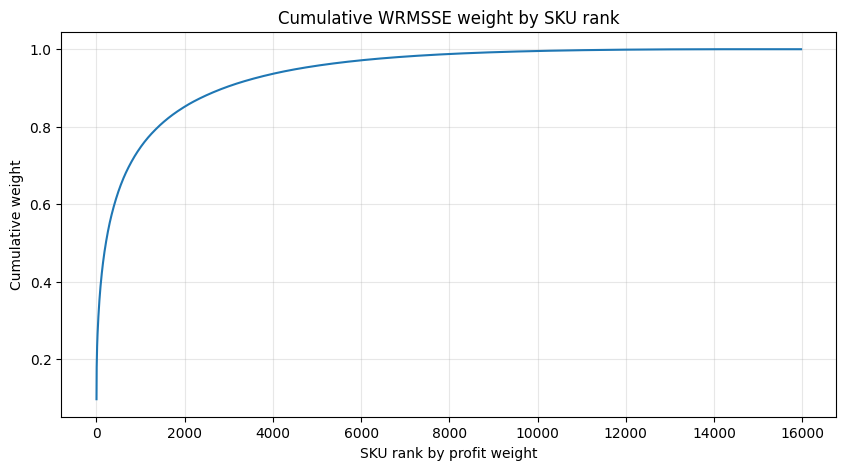

In [9]:
sku_list = sorted(df["ItemCode"].unique())
full_weight_df = compute_sku_weights(df)

weight_sorted = full_weight_df.sort_values("weight", ascending=False).reset_index(drop=True)
weight_sorted["rank"] = np.arange(1, len(weight_sorted) + 1)
weight_sorted["cum_weight"] = weight_sorted["weight"].cumsum()

top_ks = [10, 50, 100, 200, 500, 1000, 2000, 5000, len(weight_sorted)]
top_weight_table = pd.DataFrame({
    "top_k": top_ks,
    "cum_weight": [weight_sorted.loc[:k-1, "weight"].sum() for k in top_ks]
})

display(top_weight_table)
display(weight_sorted.head(30))

plt.figure(figsize=(10, 5))
plt.plot(weight_sorted["rank"], weight_sorted["cum_weight"])
plt.title("Cumulative WRMSSE weight by SKU rank")
plt.xlabel("SKU rank by profit weight")
plt.ylabel("Cumulative weight")
plt.grid(True, alpha=0.3)
plt.show()

# PHẦN 4 — Baseline cải tiến

Baseline mới gồm:
- More recent windows: `14/28/56/90` thay vì `28/56/90/180`.
- Sunday factor floor rất thấp: `0.001`.
- Rule giảm dự báo cho SKU sparse.
- Rule giảm dự báo cho SKU inactive.
- Option set SKU weight = 0 về 0.

In [10]:
def build_baseline_forecast(
    transactions,
    forecast_dates,
    sku_list,
    windows=BASELINE_WINDOWS,
    window_weights=BASELINE_WEIGHTS,
    sunday_floor=SUNDAY_FACTOR_FLOOR,
    sparse_penalty=True,
    weight_df=None,
    zero_weight_to_zero=True,
    sparse_rules=None,
    recency_rules=None
):
    assert len(windows) == len(window_weights)

    transactions = transactions.copy()
    train_end = transactions["Date"].max()
    train_start = transactions["Date"].min()
    daily_sparse = aggregate_daily_y(transactions)

    all_sku = pd.DataFrame({"ItemCode": sku_list})

    # Positive-day stats: chỉ tính ngày y > 0
    pos_daily = daily_sparse[daily_sparse["y"] > 0].copy()
    sku_stats = (
        pos_daily.groupby("ItemCode")
        .agg(
            total_y_pos=("y", "sum"),
            positive_days=("Date", "nunique"),
            last_positive_date=("Date", "max")
        )
        .reset_index()
    )

    sku_stats = all_sku.merge(sku_stats, on="ItemCode", how="left")
    sku_stats["total_y_pos"] = sku_stats["total_y_pos"].fillna(0)
    sku_stats["positive_days"] = sku_stats["positive_days"].fillna(0)
    sku_stats["last_positive_date"] = pd.to_datetime(sku_stats["last_positive_date"])
    sku_stats["days_since_last_sale"] = (train_end - sku_stats["last_positive_date"]).dt.days
    sku_stats["days_since_last_sale"] = sku_stats["days_since_last_sale"].fillna(9999)

    # Rolling window averages per SKU, chia cho số ngày window để tính cả zero days
    base = all_sku.copy()
    for w in windows:
        start = train_end - pd.Timedelta(days=w-1)
        tmp = (
            daily_sparse[(daily_sparse["Date"] >= start) & (daily_sparse["Date"] <= train_end)]
            .groupby("ItemCode")["y"].sum()
            .rename(f"sum_{w}")
            .reset_index()
        )
        base = base.merge(tmp, on="ItemCode", how="left")
        base[f"sum_{w}"] = base[f"sum_{w}"].fillna(0)
        base[f"mean_{w}"] = base[f"sum_{w}"] / w

    base["base_pred"] = 0.0
    for w, ww in zip(windows, window_weights):
        base["base_pred"] += ww * base[f"mean_{w}"]

    base = base.merge(
        sku_stats[["ItemCode", "positive_days", "days_since_last_sale"]],
        on="ItemCode",
        how="left"
    )

    # Sparse rule
    if sparse_rules is None:
        sparse_rules = [
            (1, 0.02),
            (3, 0.10),
            (7, 0.25),
            (14, 0.55),
            (28, 0.75),
        ]

    # Recency rule: áp dụng từ ngưỡng nhỏ đến lớn để SKU quá lâu không bán không bị ghi đè sai.
    if recency_rules is None:
        recency_rules = [
            (60, 0.70),
            (90, 0.50),
            (180, 0.20),
            (365, 0.00),
        ]

    if sparse_penalty:
        base["sparse_factor"] = 1.0
        for max_days, factor in sparse_rules:
            base.loc[base["positive_days"] <= max_days, "sparse_factor"] = factor

        base["recency_factor"] = 1.0
        # Important: thứ tự phải là 60 -> 90 -> 180 -> 365.
        # Nếu để 365 trước, SKU không bán rất lâu sẽ bị ghi đè lại thành 0.70.
        for min_days, factor in recency_rules:
            base.loc[base["days_since_last_sale"] > min_days, "recency_factor"] = factor

        base["base_pred"] = base["base_pred"] * base["sparse_factor"] * base["recency_factor"]

    if weight_df is not None:
        base = base.merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
        base["weight"] = base["weight"].fillna(0)
        if zero_weight_to_zero:
            base.loc[base["weight"] <= 0, "base_pred"] = 0.0

    # Global weekday factor
    total_daily = daily_sparse.groupby("Date", as_index=False)["y"].sum()
    all_train_dates = pd.DataFrame({"Date": pd.date_range(train_start, train_end, freq="D")})
    total_daily = all_train_dates.merge(total_daily, on="Date", how="left").fillna({"y": 0})
    total_daily["dow"] = total_daily["Date"].dt.dayofweek

    weekday_mean = total_daily.groupby("dow")["y"].mean()
    global_mean = total_daily["y"].mean()
    weekday_factor = (weekday_mean / max(global_mean, EPS)).clip(lower=0.0, upper=2.0).to_dict()

    # Chủ nhật: dùng floor rất thấp để tránh dự báo Chủ nhật quá cao
    weekday_factor[6] = max(float(weekday_factor.get(6, sunday_floor)), sunday_floor)

    # Cross join SKU x forecast_dates
    fdates = pd.DataFrame({"Date": forecast_dates})
    fdates["dow"] = fdates["Date"].dt.dayofweek
    fdates["weekday_factor"] = fdates["dow"].map(weekday_factor).fillna(1.0)

    pred = base[["ItemCode", "base_pred"]].merge(fdates, how="cross")
    pred["pred"] = pred["base_pred"] * pred["weekday_factor"]
    pred["pred"] = pred["pred"].clip(lower=0)

    return pred[["ItemCode", "Date", "pred"]], base, weekday_factor

In [11]:
def build_baseline_model_forecast(
    transactions,
    forecast_dates,
    sku_list,
    cfg=None,
    weight_df=None,
    zero_weight_to_zero=True,
    use_ensemble=USE_BASELINE_ENSEMBLE,
):
    """
    Wrapper cho baseline:
    - cfg != None: dùng đúng một cấu hình baseline, thường dùng khi grid-search.
    - use_ensemble=True: ensemble fast/stable/long baseline.
    - mặc định: dùng BASELINE_WINDOWS / BASELINE_WEIGHTS đang set ở CONFIG.
    """
    if cfg is not None:
        return build_baseline_forecast(
            transactions,
            forecast_dates,
            sku_list,
            windows=cfg["windows"],
            window_weights=cfg["weights"],
            sunday_floor=cfg.get("sunday_floor", SUNDAY_FACTOR_FLOOR),
            sparse_penalty=cfg.get("sparse_penalty", True),
            weight_df=weight_df,
            zero_weight_to_zero=cfg.get("zero_weight_to_zero", zero_weight_to_zero),
        )

    if not use_ensemble:
        return build_baseline_forecast(
            transactions,
            forecast_dates,
            sku_list,
            windows=BASELINE_WINDOWS,
            window_weights=BASELINE_WEIGHTS,
            sunday_floor=SUNDAY_FACTOR_FLOOR,
            sparse_penalty=True,
            weight_df=weight_df,
            zero_weight_to_zero=zero_weight_to_zero,
        )

    pred_frames = []
    base_tables = []
    weekday_factors = {}
    total_weight = sum(c["ensemble_weight"] for c in BASELINE_ENSEMBLE_CONFIGS)

    for cfg_i in BASELINE_ENSEMBLE_CONFIGS:
        pred_i, base_i, wf_i = build_baseline_forecast(
            transactions,
            forecast_dates,
            sku_list,
            windows=cfg_i["windows"],
            window_weights=cfg_i["weights"],
            sunday_floor=SUNDAY_FACTOR_FLOOR,
            sparse_penalty=True,
            weight_df=weight_df,
            zero_weight_to_zero=zero_weight_to_zero,
        )
        pred_i = pred_i.rename(columns={"pred": f"pred_{cfg_i['name']}"})
        pred_i[f"pred_{cfg_i['name']}"] *= cfg_i["ensemble_weight"] / total_weight
        pred_frames.append(pred_i)
        base_i["baseline_name"] = cfg_i["name"]
        base_tables.append(base_i)
        weekday_factors[cfg_i["name"]] = wf_i

    out = pred_frames[0]
    for p in pred_frames[1:]:
        out = out.merge(p, on=["ItemCode", "Date"], how="left")

    pred_cols = [c for c in out.columns if c.startswith("pred_")]
    out["pred"] = out[pred_cols].sum(axis=1).clip(lower=0)
    base_table = pd.concat(base_tables, ignore_index=True)
    return out[["ItemCode", "Date", "pred"]], base_table, weekday_factors


def apply_special_sku_multipliers(pred_long, multipliers=None, enabled=USE_SPECIAL_SKU_MULTIPLIER):
    """Optional rule thủ công cho top contribution SKU. Mặc định tắt để tránh overfit."""
    if multipliers is None:
        multipliers = SPECIAL_SKU_MULTIPLIER
    out = pred_long.copy()
    if not enabled or len(multipliers) == 0:
        return out
    for sku, mult in multipliers.items():
        out.loc[out["ItemCode"] == sku, "pred"] *= float(mult)
    out["pred"] = out["pred"].clip(lower=0)
    return out

# PHẦN 5 — Single-fold validation + top contribution

Phần này dùng **28 ngày cuối train** làm validation nội bộ để sát Public/Private leaderboard hơn:
- Train: từ đầu đến trước 28 ngày cuối.
- Valid: 28 ngày cuối.

Sau đó tạo bảng:
```text
contribution = weight × RMSSE
```

Đây là bảng quan trọng nhất để biết SKU nào đang kéo điểm.

In [12]:
def make_single_validation_split(transactions, horizon=56):
    max_date = transactions["Date"].max()
    valid_start = max_date - pd.Timedelta(days=horizon - 1)
    valid_end = max_date
    train_part = transactions[transactions["Date"] < valid_start].copy()
    valid_part = transactions[(transactions["Date"] >= valid_start) & (transactions["Date"] <= valid_end)].copy()
    valid_dates = pd.date_range(valid_start, valid_end, freq="D")
    return train_part, valid_part, valid_dates, valid_start, valid_end


H = VALIDATION_HORIZON
train_part, valid_part, valid_dates, valid_start, valid_end = make_single_validation_split(df, horizon=H)

print("Train:", train_part["Date"].min(), "->", train_part["Date"].max(), train_part.shape)
print("Valid:", valid_start, "->", valid_end, valid_part.shape)

train_daily_part = aggregate_daily_y(train_part)
valid_daily_part = aggregate_daily_y(valid_part)
weight_part = compute_sku_weights(train_part)

train_dates = pd.date_range(train_part["Date"].min(), train_part["Date"].max(), freq="D")
scale_part = compute_rmsse_scale(train_daily_part, sku_list, train_dates)
actual_valid_long = make_actual_matrix_long(valid_daily_part, sku_list, valid_dates)

baseline_valid_pred, baseline_base_table, weekday_factor = build_baseline_model_forecast(
    train_part,
    valid_dates,
    sku_list,
    weight_df=weight_part,
    zero_weight_to_zero=True,
    use_ensemble=USE_BASELINE_ENSEMBLE,
)
baseline_valid_pred = apply_special_sku_multipliers(baseline_valid_pred)

baseline_score, baseline_sku_eval, baseline_eval_df = wrmsse_score(
    actual_valid_long,
    baseline_valid_pred,
    scale_part,
    weight_part
)

print("Improved baseline WRMSSE:", baseline_score)
print("Weekday factor:", weekday_factor)
display(baseline_sku_eval.sort_values("contribution", ascending=False).head(30))

Train: 2020-11-17 00:00:00 -> 2025-08-08 00:00:00 (701077, 15)
Valid: 2025-08-09 00:00:00 -> 2025-09-05 00:00:00 (10903, 15)
Improved baseline WRMSSE: 0.5483951374067948
Weekday factor: {0: 1.2618686939214538, 1: 1.1744478895180965, 2: 1.2254248092726476, 3: 1.2233061352716488, 4: 1.2230990257920267, 5: 0.886811504603317, 6: 0.0016017877189625593}


,ItemCode,mse,scale,weight,actual_sum,pred_sum,rmsse,contribution
2,SKU-00003,116.376690,58.401741,0.095366,356,290.359455,1.411627,0.134621
1,SKU-00002,38.261434,24.375652,0.046682,98,234.338111,1.252860,0.058487
15241,SKU-15599,"35,436.889841","3,104.949463",0.002700,1236,233.651782,3.378318,0.009123
13993,SKU-14323,"1,495.502750","1,787.867798",0.005412,628,464.429421,0.914589,0.004950
14419,SKU-14763,"1,117.273280",155.885223,0.001441,298,56.318975,2.677178,0.003857
13990,SKU-14320,821.769159,"1,726.381470",0.005130,437,361.071353,0.689932,0.003539
3248,SKU-03351,"8,637.954224","1,530.994751",0.001476,732,0.655233,2.375301,0.003506
1042,SKU-01074,306.825092,25.414494,0.000845,123,0.457109,3.474599,0.002935
13973,SKU-14303,669.541447,357.848694,0.002104,406,126.937586,1.367852,0.002878
5801,SKU-05957,0.677158,0.126377,0.001044,7,0.065301,2.314789,0.002418


,ItemCode,mse,scale,weight,actual_sum,pred_sum,rmsse,contribution,rank_contribution,cum_contribution,contribution_share,cum_contribution_share
0,SKU-00003,116.376690,58.401741,0.095366,356,290.359455,1.411627,0.134621,1,0.134621,0.245482,0.245482
1,SKU-00002,38.261434,24.375652,0.046682,98,234.338111,1.252860,0.058487,2,0.193108,0.106651,0.352133
2,SKU-15599,"35,436.889841","3,104.949463",0.002700,1236,233.651782,3.378318,0.009123,3,0.202230,0.016635,0.368768
3,SKU-14323,"1,495.502750","1,787.867798",0.005412,628,464.429421,0.914589,0.004950,4,0.207181,0.009026,0.377794
4,SKU-14763,"1,117.273280",155.885223,0.001441,298,56.318975,2.677178,0.003857,5,0.211038,0.007033,0.384828
5,SKU-14320,821.769159,"1,726.381470",0.005130,437,361.071353,0.689932,0.003539,6,0.214577,0.006454,0.391282
6,SKU-03351,"8,637.954224","1,530.994751",0.001476,732,0.655233,2.375301,0.003506,7,0.218082,0.006392,0.397674
7,SKU-01074,306.825092,25.414494,0.000845,123,0.457109,3.474599,0.002935,8,0.221017,0.005351,0.403025
8,SKU-14303,669.541447,357.848694,0.002104,406,126.937586,1.367852,0.002878,9,0.223895,0.005248,0.408274
9,SKU-05957,0.677158,0.126377,0.001044,7,0.065301,2.314789,0.002418,10,0.226313,0.004408,0.412682


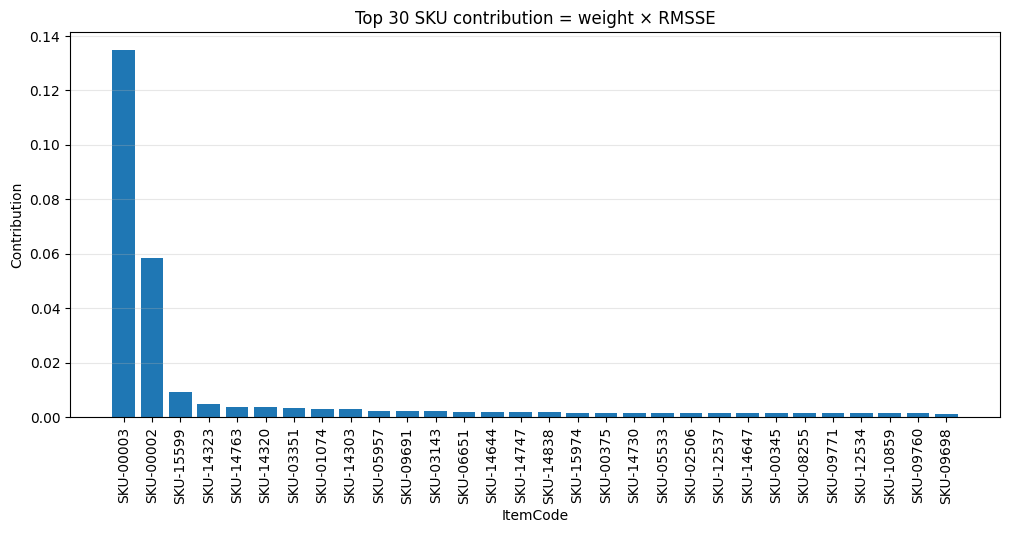

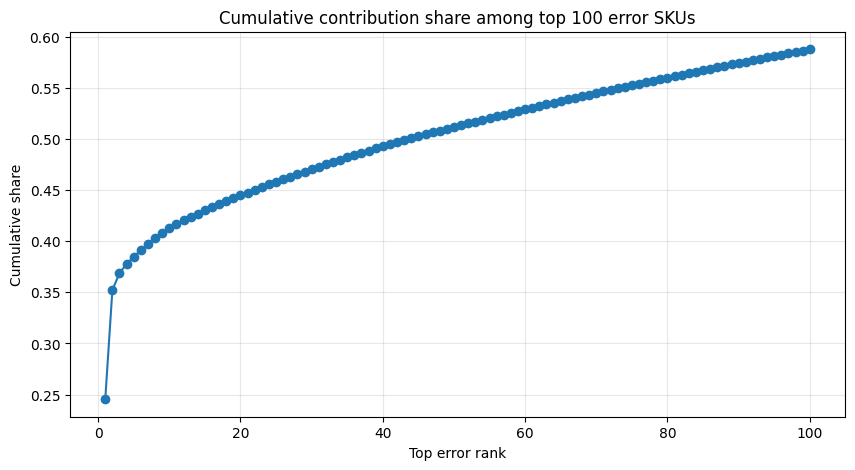

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum,raw_ratio_actual_over_pred,suggested_multiplier
2,SKU-00003,0.095366,1.411627,0.134621,356,290.359455,1.226066,1.226066
1,SKU-00002,0.046682,1.252860,0.058487,98,234.338111,0.418199,0.700000
15241,SKU-15599,0.002700,3.378318,0.009123,1236,233.651782,5.289923,1.300000
13993,SKU-14323,0.005412,0.914589,0.004950,628,464.429421,1.352197,1.300000
14419,SKU-14763,0.001441,2.677178,0.003857,298,56.318975,5.291289,1.300000
13990,SKU-14320,0.005130,0.689932,0.003539,437,361.071353,1.210287,1.210287
3248,SKU-03351,0.001476,2.375301,0.003506,732,0.655233,"1,117.159198",1.300000
1042,SKU-01074,0.000845,3.474599,0.002935,123,0.457109,269.082678,1.300000
13973,SKU-14303,0.002104,1.367852,0.002878,406,126.937586,3.198422,1.300000
5801,SKU-05957,0.001044,2.314789,0.002418,7,0.065301,107.195538,1.300000


Nếu muốn apply rule thủ công, hãy copy các SKU đã kiểm chứng vào SPECIAL_SKU_MULTIPLIER và bật USE_SPECIAL_SKU_MULTIPLIER=True.


In [13]:
def build_top_contribution_table(sku_eval, top_n=100):
    out = sku_eval.copy()
    out = out.sort_values("contribution", ascending=False).reset_index(drop=True)
    out["rank_contribution"] = np.arange(1, len(out) + 1)
    out["cum_contribution"] = out["contribution"].cumsum()
    total = out["contribution"].sum()
    out["contribution_share"] = np.where(total > 0, out["contribution"] / total, 0)
    out["cum_contribution_share"] = out["contribution_share"].cumsum()
    return out.head(top_n)

top_contrib = build_top_contribution_table(baseline_sku_eval, top_n=100)
display(top_contrib.head(30))

plt.figure(figsize=(12, 5))
plt.bar(top_contrib.head(30)["ItemCode"], top_contrib.head(30)["contribution"])
plt.title("Top 30 SKU contribution = weight × RMSSE")
plt.xlabel("ItemCode")
plt.ylabel("Contribution")
plt.xticks(rotation=90)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(top_contrib)+1), top_contrib["cum_contribution_share"], marker="o")
plt.title("Cumulative contribution share among top 100 error SKUs")
plt.xlabel("Top error rank")
plt.ylabel("Cumulative share")
plt.grid(True, alpha=0.3)
plt.show()


def suggest_special_multipliers(sku_eval, top_n=30, min_actual_sum=1, lower=0.70, upper=1.30):
    """
    Gợi ý multiplier cho top contribution SKU dựa trên actual_sum / pred_sum.
    Chỉ dùng để tham khảo/EDA; không tự apply vào final nếu USE_SPECIAL_SKU_MULTIPLIER=False.
    """
    tmp = sku_eval.sort_values("contribution", ascending=False).head(top_n).copy()
    tmp["raw_ratio_actual_over_pred"] = tmp["actual_sum"] / tmp["pred_sum"].replace(0, np.nan)
    tmp["suggested_multiplier"] = tmp["raw_ratio_actual_over_pred"].replace([np.inf, -np.inf], np.nan)
    tmp["suggested_multiplier"] = tmp["suggested_multiplier"].fillna(1.0).clip(lower, upper)
    tmp.loc[tmp["actual_sum"] < min_actual_sum, "suggested_multiplier"] = 1.0
    return tmp[[
        "ItemCode", "weight", "rmsse", "contribution", "actual_sum", "pred_sum",
        "raw_ratio_actual_over_pred", "suggested_multiplier"
    ]]

special_multiplier_suggestions = suggest_special_multipliers(baseline_sku_eval, top_n=30)
display(special_multiplier_suggestions)
print("Nếu muốn apply rule thủ công, hãy copy các SKU đã kiểm chứng vào SPECIAL_SKU_MULTIPLIER và bật USE_SPECIAL_SKU_MULTIPLIER=True.")

# PHẦN 6 — Plot riêng top 30 SKU gây lỗi lớn

Phần này plot actual vs prediction trong validation cho top 30 SKU có contribution cao nhất.
Dùng để xem SKU bị:
- Over-predict.
- Under-predict.
- Lệch trend.
- Lỗi do ngày Chủ nhật/cuối tuần.

['SKU-00003', 'SKU-00002', 'SKU-15599', 'SKU-14323', 'SKU-14763', 'SKU-14320', 'SKU-03351', 'SKU-01074', 'SKU-14303', 'SKU-05957', 'SKU-09691', 'SKU-03143', 'SKU-06651', 'SKU-14644', 'SKU-14747', 'SKU-14838', 'SKU-15974', 'SKU-00375', 'SKU-14730', 'SKU-05533', 'SKU-02506', 'SKU-12537', 'SKU-14647', 'SKU-00345', 'SKU-08255', 'SKU-09771', 'SKU-12534', 'SKU-10859', 'SKU-09760', 'SKU-09698']


,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
2,SKU-00003,0.095366,1.411627,0.134621,356,290.359455


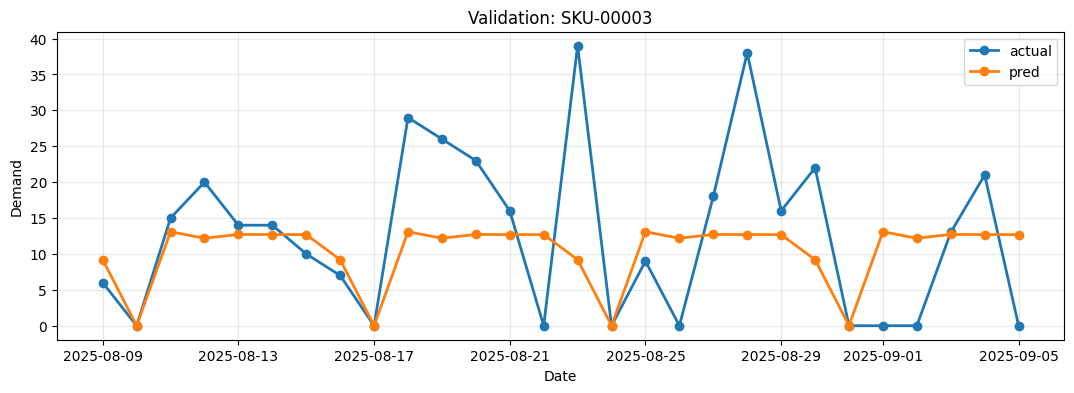

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
1,SKU-00002,0.046682,1.252860,0.058487,98,234.338111


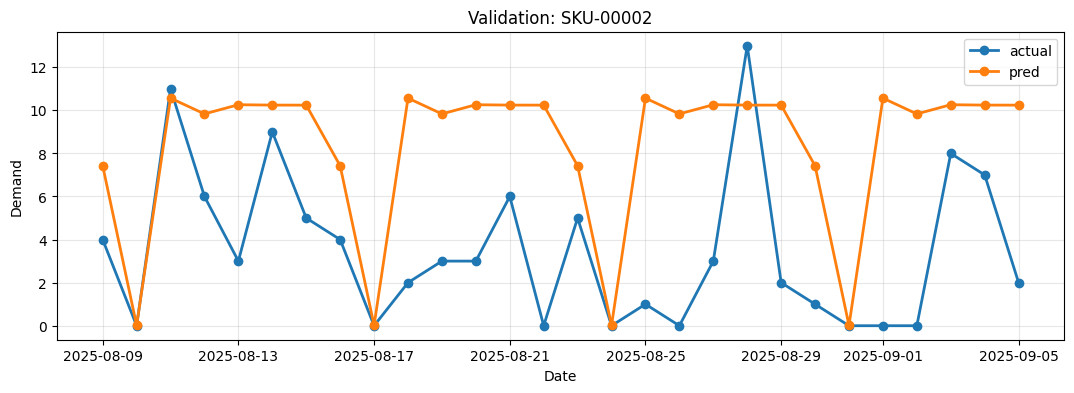

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
15241,SKU-15599,0.002700,3.378318,0.009123,1236,233.651782


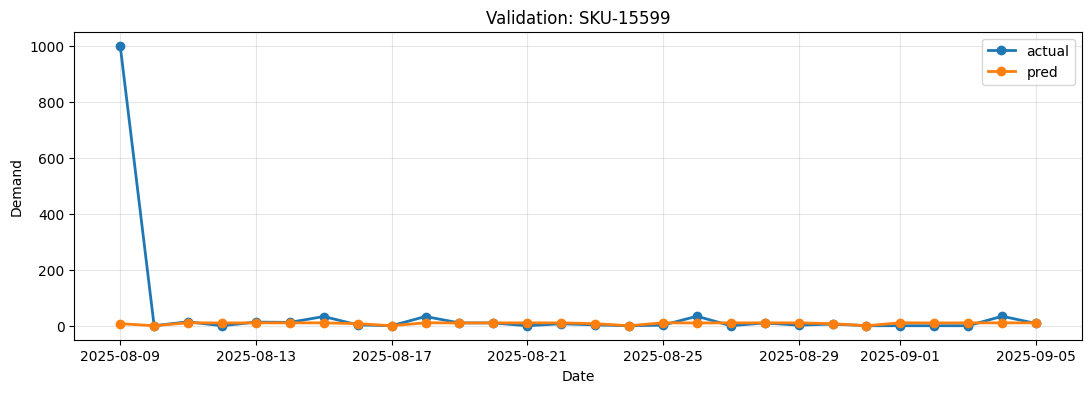

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
13993,SKU-14323,0.005412,0.914589,0.004950,628,464.429421


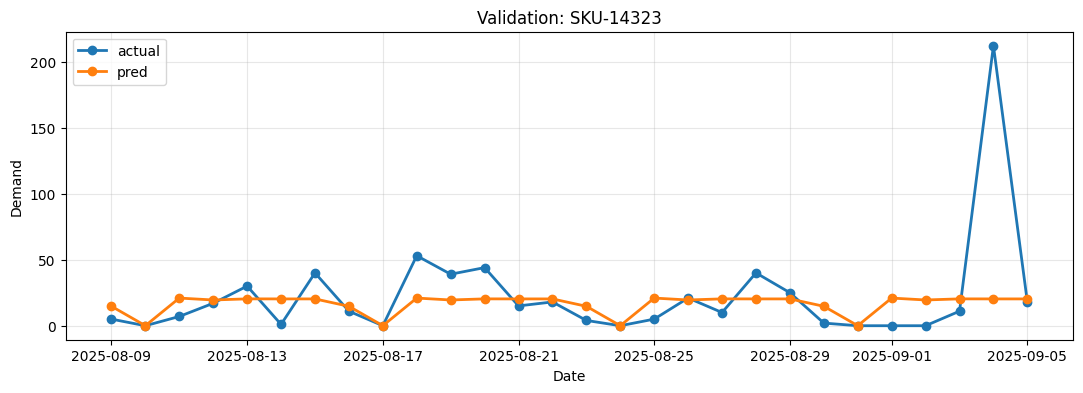

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14419,SKU-14763,0.001441,2.677178,0.003857,298,56.318975


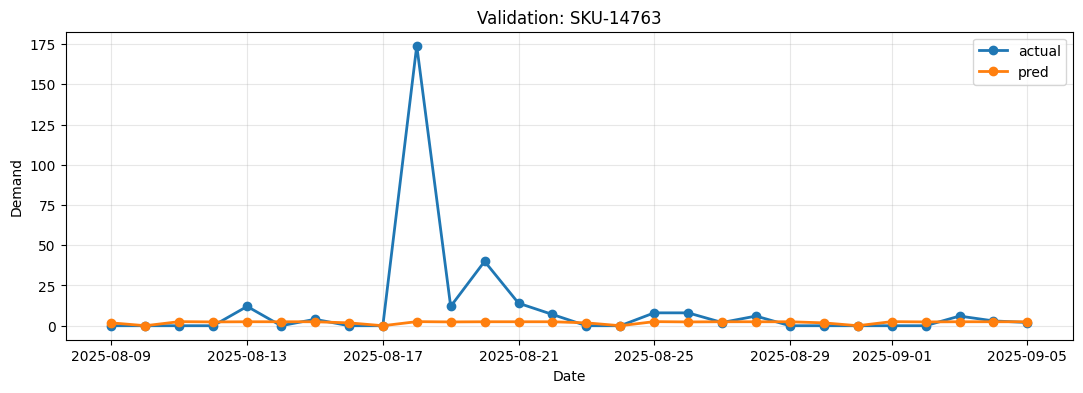

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
13990,SKU-14320,0.005130,0.689932,0.003539,437,361.071353


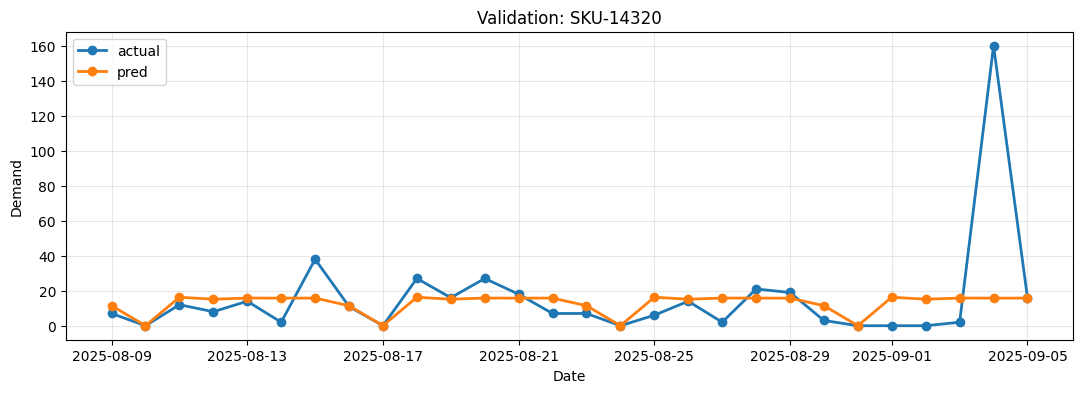

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
3248,SKU-03351,0.001476,2.375301,0.003506,732,0.655233


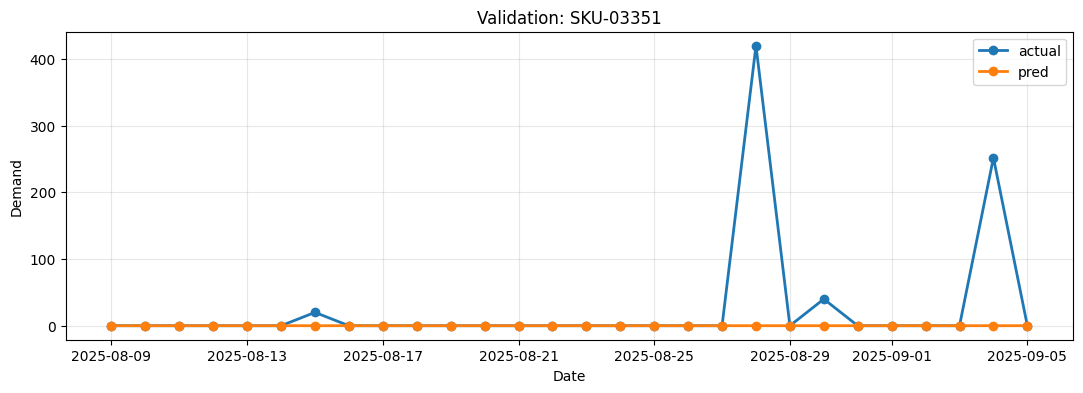

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
1042,SKU-01074,0.000845,3.474599,0.002935,123,0.457109


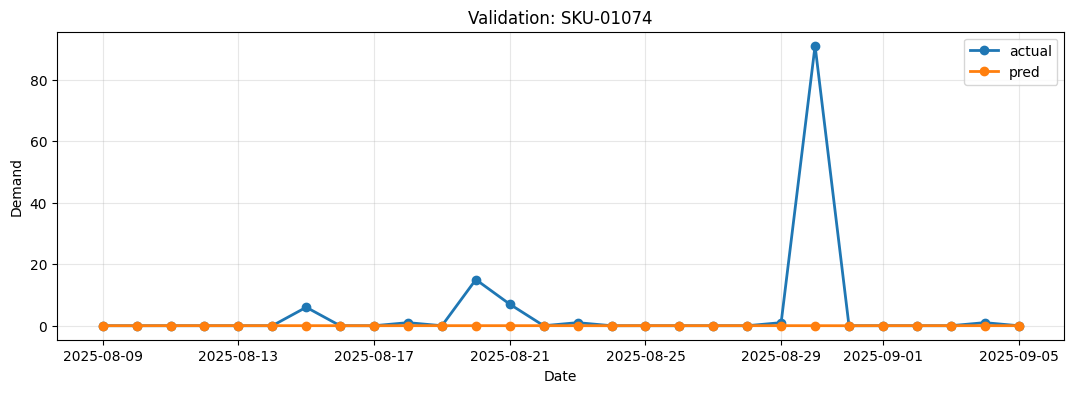

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
13973,SKU-14303,0.002104,1.367852,0.002878,406,126.937586


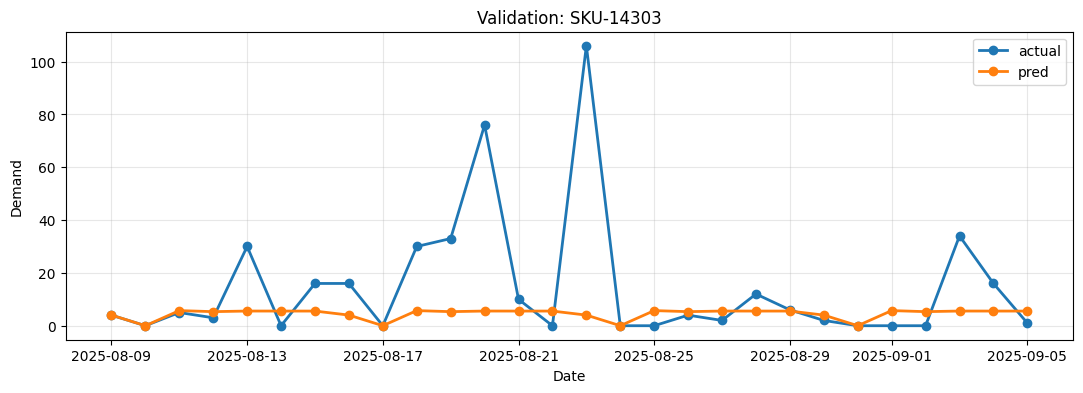

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
5801,SKU-05957,0.001044,2.314789,0.002418,7,0.065301


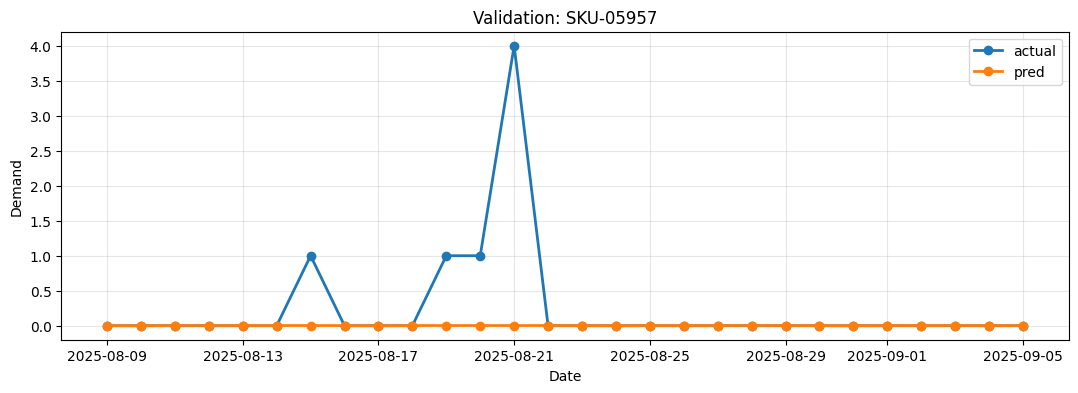

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9424,SKU-09691,0.001054,2.004459,0.002113,26,0.000000


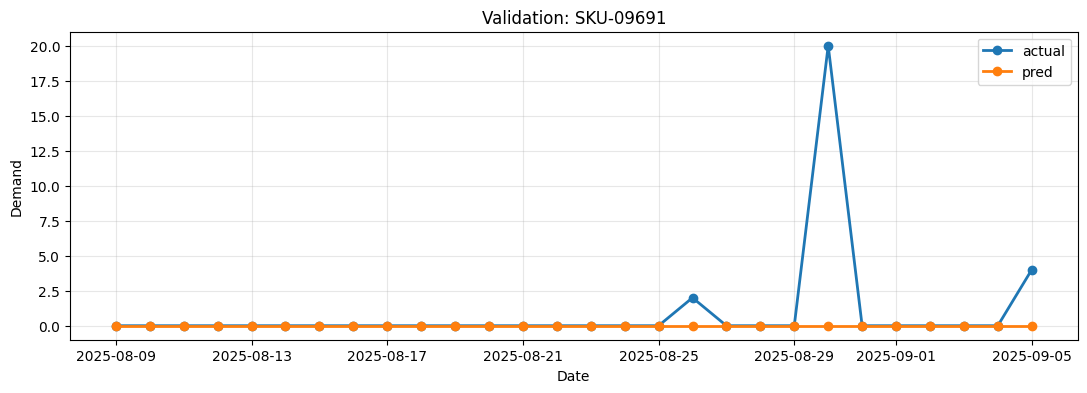

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
3048,SKU-03143,0.002977,0.695389,0.002070,77,0.065301


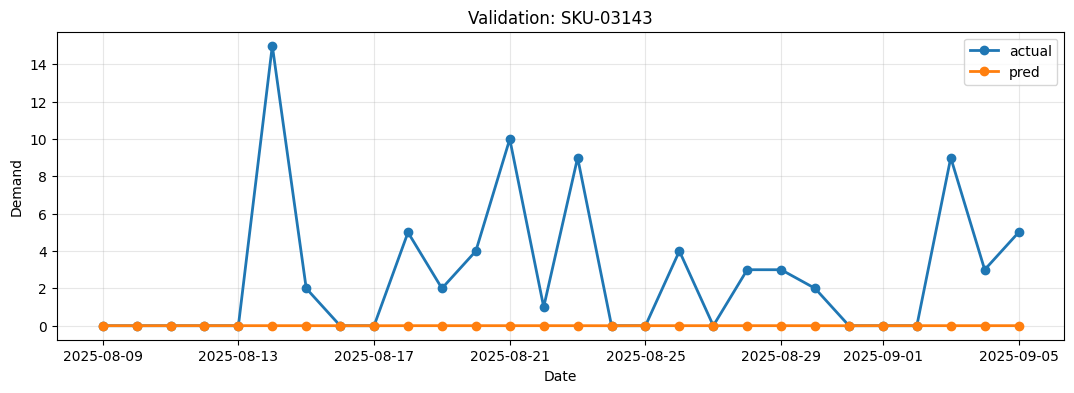

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
6476,SKU-06651,0.001160,1.536939,0.001783,140,86.728467


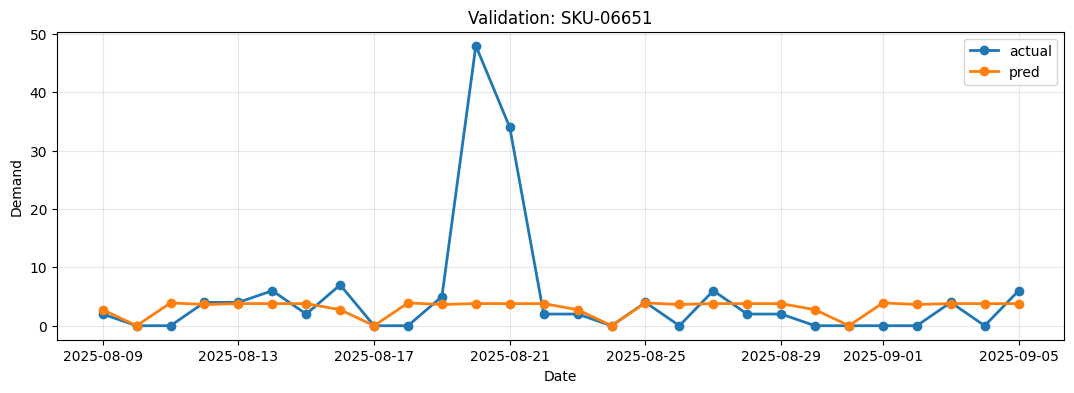

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14306,SKU-14644,0.001973,0.899002,0.001774,150,152.947019


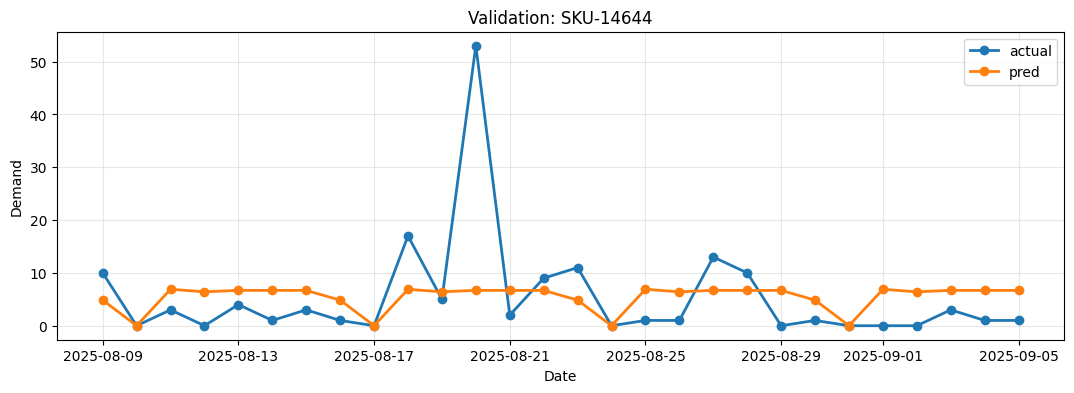

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14403,SKU-14747,0.001269,1.392688,0.001767,206,103.333636


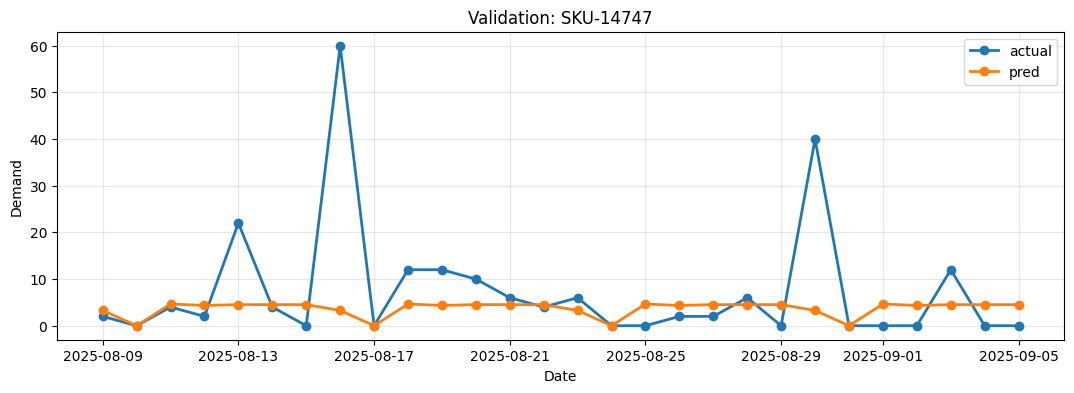

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14492,SKU-14838,0.000992,1.771358,0.001756,198,78.450315


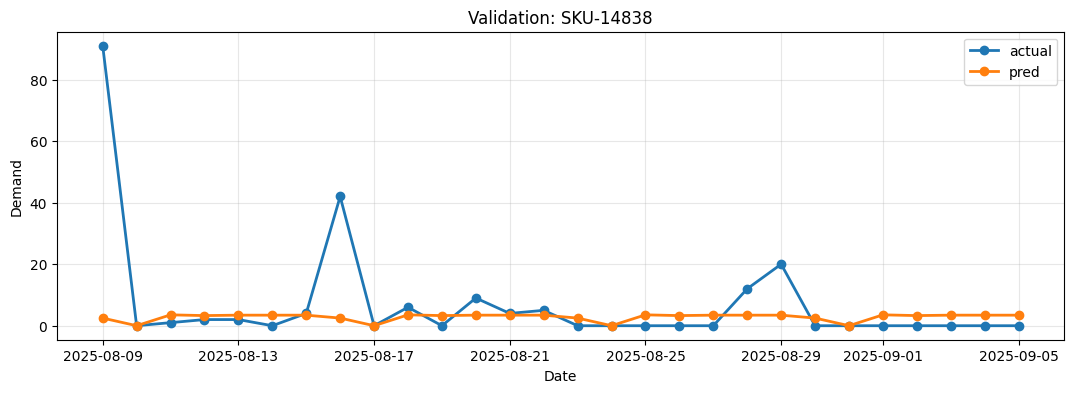

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
15613,SKU-15974,0.001393,1.209017,0.001685,137,95.293145


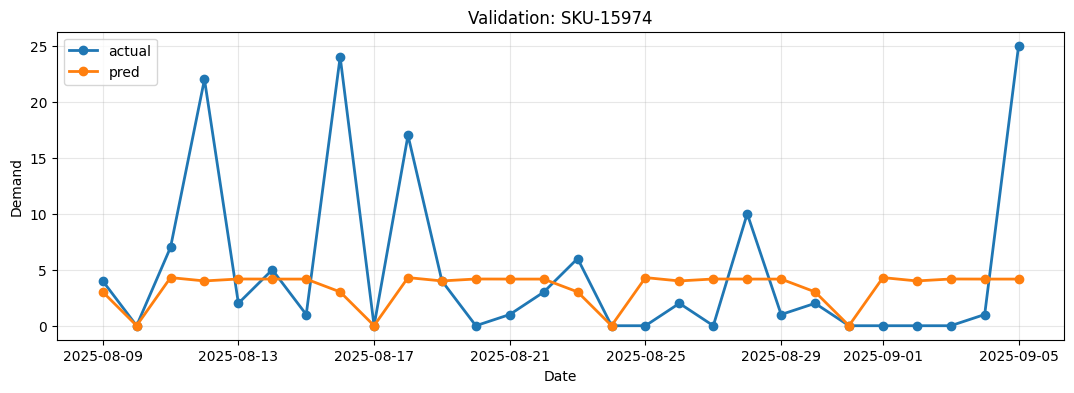

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
364,SKU-00375,0.002045,0.778217,0.001591,24,10.290496


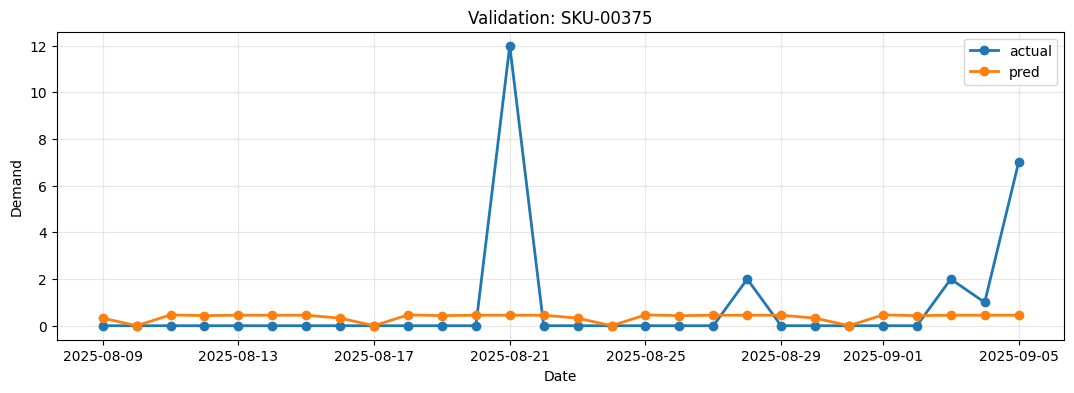

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14387,SKU-14730,0.002575,0.600299,0.001546,265,71.344920


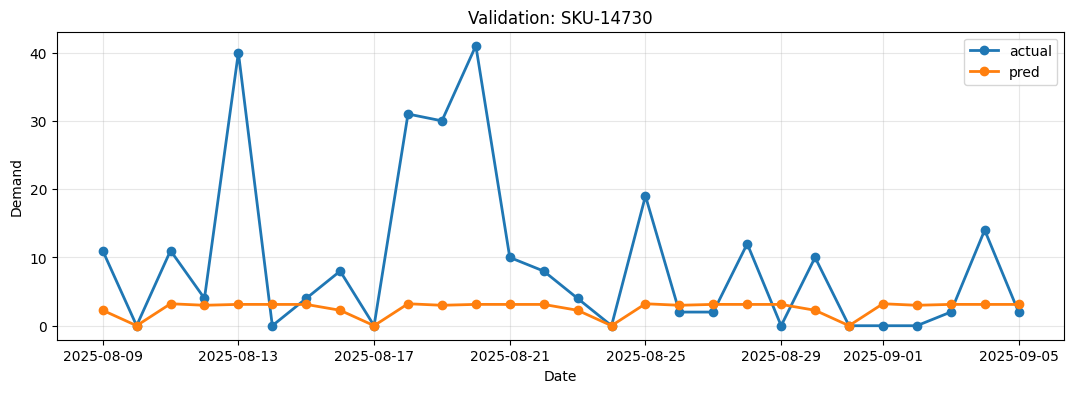

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
5384,SKU-05533,0.000426,3.626018,0.001545,12,4.140187


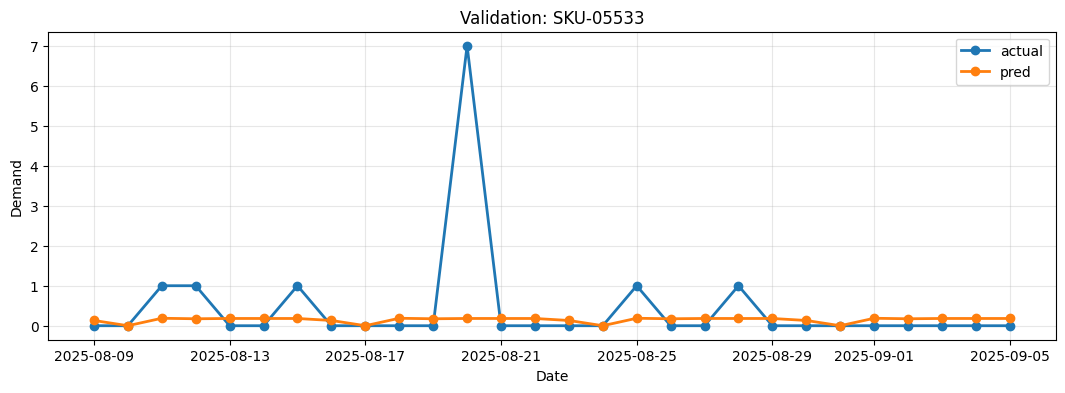

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
2432,SKU-02506,0.000860,1.729235,0.001487,25,21.484992


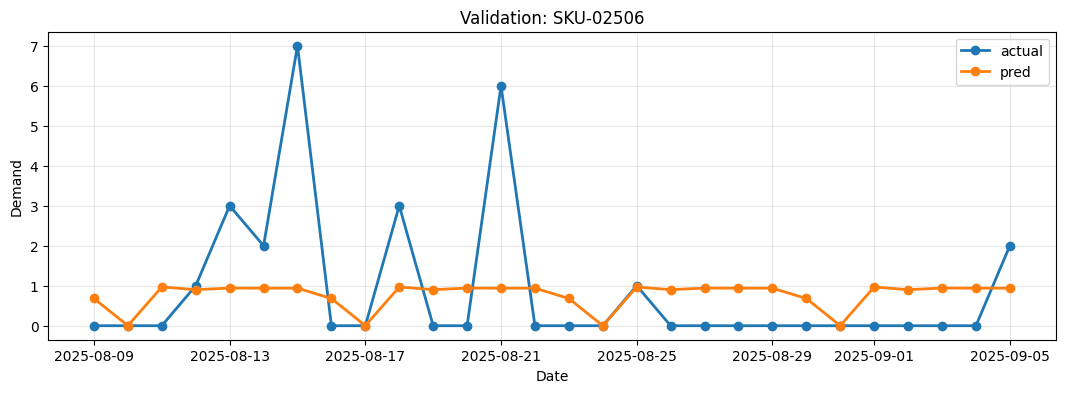

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
12230,SKU-12537,0.006507,0.223655,0.001455,44,322.332623


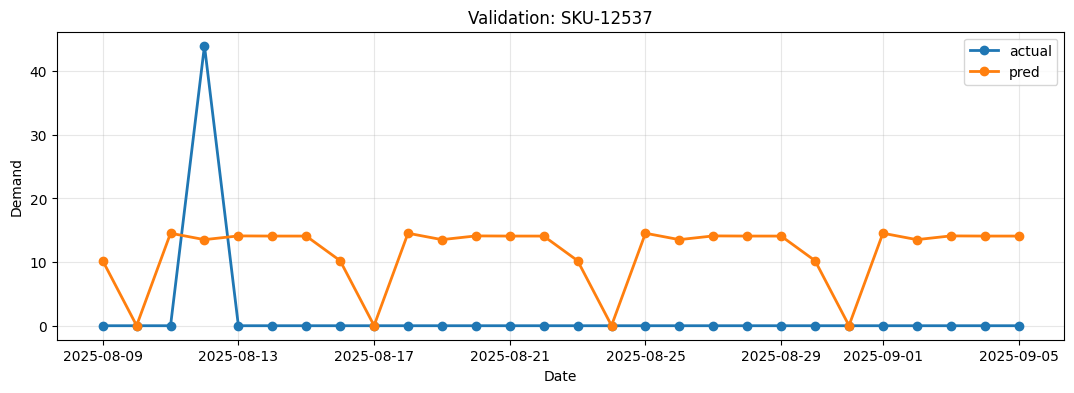

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
14309,SKU-14647,0.001888,0.770303,0.001454,143,189.613435


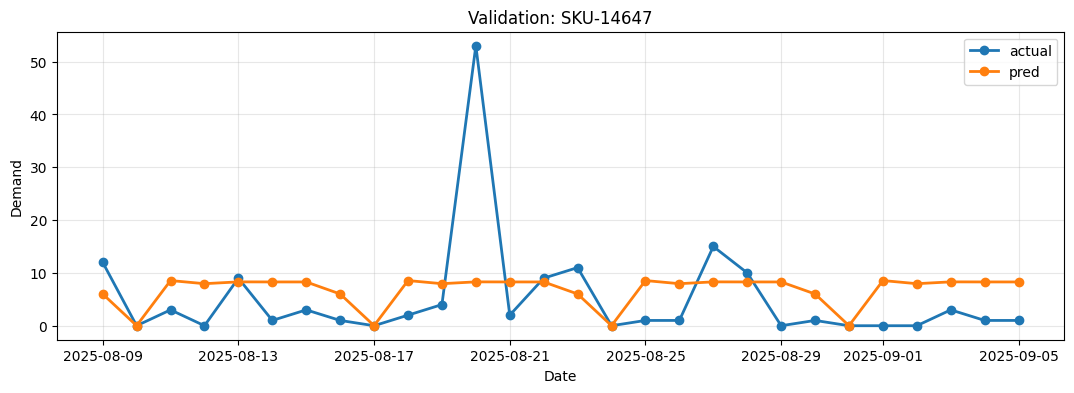

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
336,SKU-00345,0.001119,1.296168,0.001451,127,253.764115


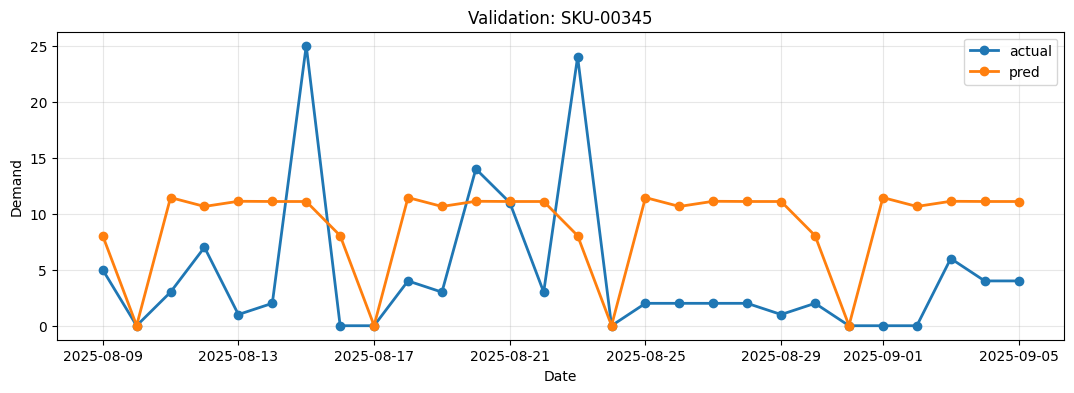

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
8029,SKU-08255,0.000154,9.234822,0.001419,6,0.016325


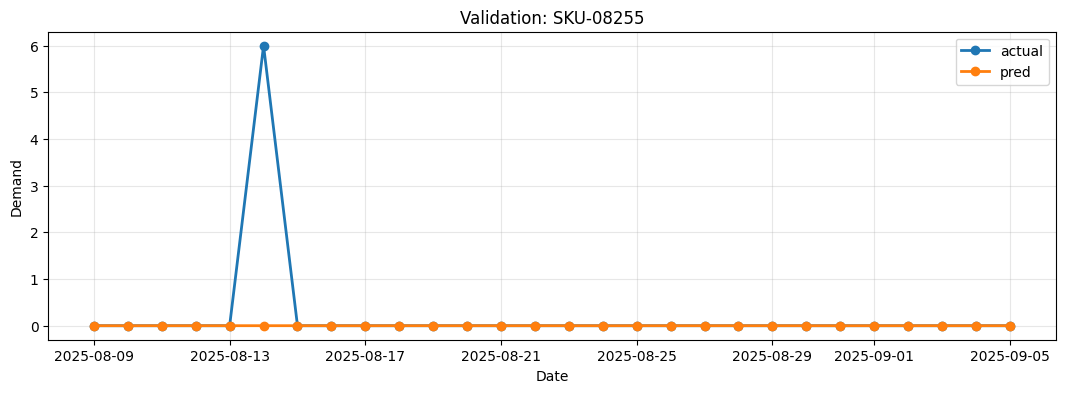

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9503,SKU-09771,0.001268,1.076172,0.001365,36,25.938357


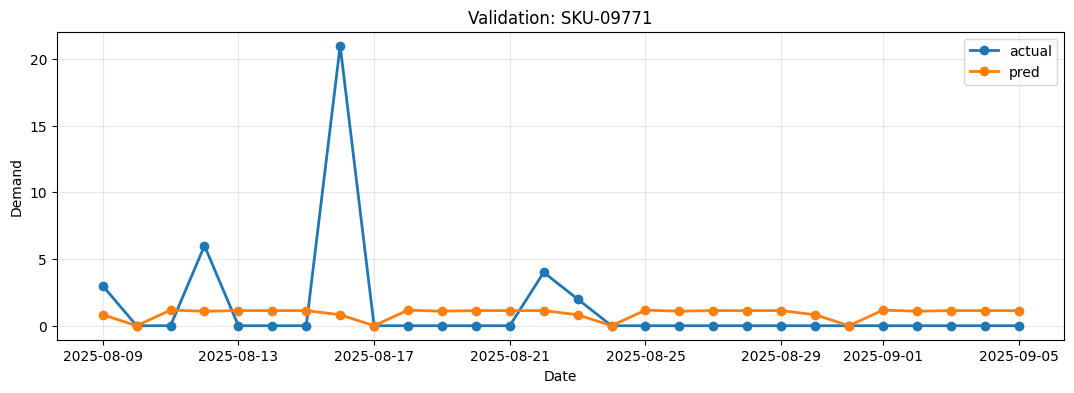

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
12229,SKU-12534,0.007114,0.191388,0.001362,166,315.322736


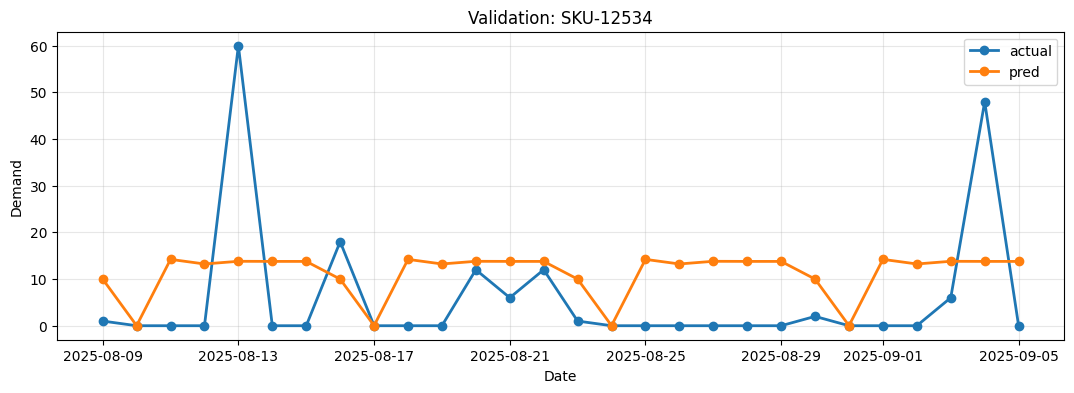

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
10570,SKU-10859,0.000704,1.906608,0.001341,51,0.697435


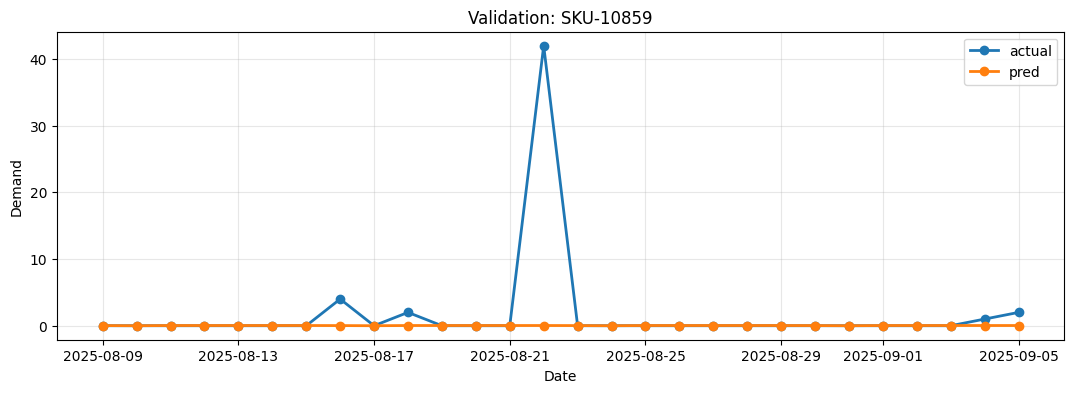

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9492,SKU-09760,0.006967,0.190760,0.001329,2338,"2,759.254407"


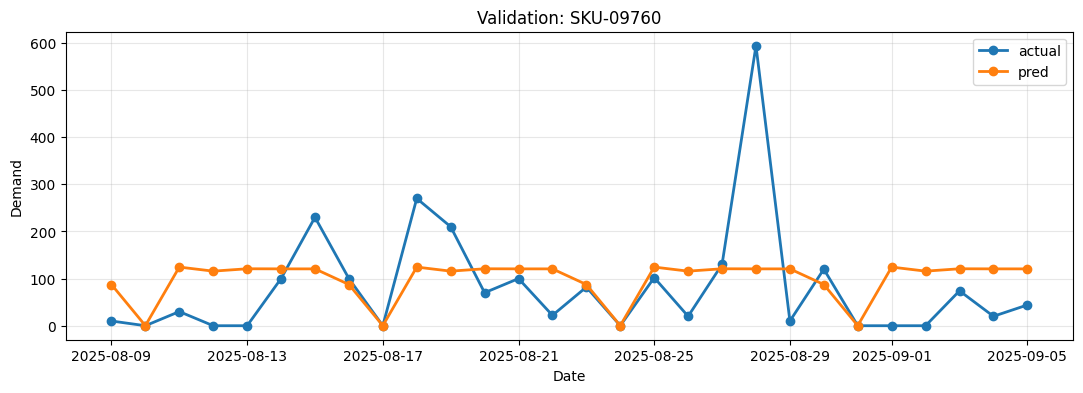

,ItemCode,weight,rmsse,contribution,actual_sum,pred_sum
9431,SKU-09698,0.002237,0.586358,0.001312,22,0.497533


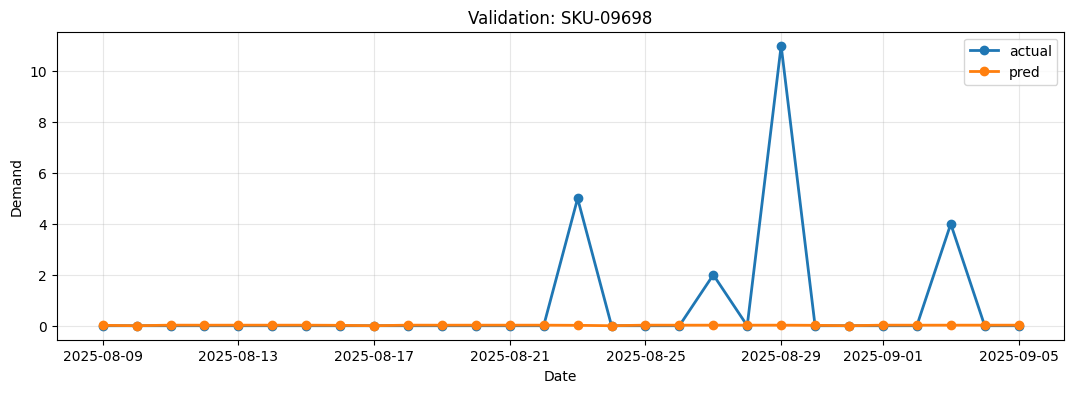

In [14]:
def plot_validation_sku(item_code, eval_df, title_prefix="Validation"):
    tmp = eval_df[eval_df["ItemCode"] == item_code].copy().sort_values("Date")
    if tmp.empty:
        print("No data for", item_code)
        return

    info = (
        baseline_sku_eval[baseline_sku_eval["ItemCode"] == item_code]
        [["ItemCode", "weight", "rmsse", "contribution", "actual_sum", "pred_sum"]]
    )
    display(info)

    plt.figure(figsize=(13, 4))
    plt.plot(tmp["Date"], tmp["actual"], marker="o", label="actual", linewidth=2)
    plt.plot(tmp["Date"], tmp["pred"], marker="o", label="pred", linewidth=2)
    plt.title(f"{title_prefix}: {item_code}")
    plt.xlabel("Date")
    plt.ylabel("Demand")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


TOP_ERROR_N = 30
top_error_skus = top_contrib.head(TOP_ERROR_N)["ItemCode"].tolist()
print(top_error_skus)

for sku in top_error_skus:
    plot_validation_sku(sku, baseline_eval_df)

# PHẦN 7 — Tune nhanh baseline rules

Phần này so sánh vài cấu hình baseline:
- Baseline cũ.
- Baseline recent.
- Recent + sparse/inactive rule mạnh.
- Recent + không set weight=0 về 0.

Chọn config tốt nhất theo validation nội bộ.

In [15]:
baseline_configs = [
    {
        "name": "old_windows_28_56_90_180",
        "windows": (28, 56, 90, 180),
        "weights": (0.35, 0.30, 0.20, 0.15),
        "sunday_floor": 0.05,
        "zero_weight_to_zero": False,
        "sparse_penalty": True,
    },
    {
        "name": "recent_14_28_56_90",
        "windows": (14, 28, 56, 90),
        "weights": (0.40, 0.30, 0.20, 0.10),
        "sunday_floor": 0.001,
        "zero_weight_to_zero": True,
        "sparse_penalty": True,
    },
    {
        "name": "recent_more_weight_14",
        "windows": (14, 28, 56, 90),
        "weights": (0.50, 0.25, 0.15, 0.10),
        "sunday_floor": 0.001,
        "zero_weight_to_zero": True,
        "sparse_penalty": True,
    },
    {
        "name": "recent_less_sparse_penalty",
        "windows": (14, 28, 56, 90),
        "weights": (0.40, 0.30, 0.20, 0.10),
        "sunday_floor": 0.001,
        "zero_weight_to_zero": True,
        "sparse_penalty": False,
    },
]

baseline_tune_rows = []

for cfg in baseline_configs:
    pred, base_table, wf = build_baseline_forecast(
        train_part,
        valid_dates,
        sku_list,
        windows=cfg["windows"],
        window_weights=cfg["weights"],
        sunday_floor=cfg["sunday_floor"],
        sparse_penalty=cfg["sparse_penalty"],
        weight_df=weight_part,
        zero_weight_to_zero=cfg["zero_weight_to_zero"]
    )
    score, sku_eval_tmp, eval_tmp = wrmsse_score(actual_valid_long, pred, scale_part, weight_part)
    baseline_tune_rows.append({
        "name": cfg["name"],
        "score": score,
        "windows": cfg["windows"],
        "weights": cfg["weights"],
        "sunday_floor": cfg["sunday_floor"],
        "sparse_penalty": cfg["sparse_penalty"],
        "zero_weight_to_zero": cfg["zero_weight_to_zero"],
    })

baseline_tune = pd.DataFrame(baseline_tune_rows).sort_values("score")
display(baseline_tune)

,name,score,windows,weights,sunday_floor,sparse_penalty,zero_weight_to_zero
1,recent_14_28_56_90,0.548395,"(14, 28, 56, 90)","(0.4, 0.3, 0.2, 0.1)",0.001000,True,True
2,recent_more_weight_14,0.548596,"(14, 28, 56, 90)","(0.5, 0.25, 0.15, 0.1)",0.001000,True,True
3,recent_less_sparse_penalty,0.549888,"(14, 28, 56, 90)","(0.4, 0.3, 0.2, 0.1)",0.001000,False,True
0,old_windows_28_56_90_180,0.550718,"(28, 56, 90, 180)","(0.35, 0.3, 0.2, 0.15)",0.050000,True,False


# PHẦN 8 — Rolling validation cho baseline

Không nên tin một validation split duy nhất.
Phần này tạo 3 folds, mỗi fold forecast 56 ngày.

Ví dụ:
- Fold 1: 56 ngày cuối.
- Fold 2: lùi lại 28 ngày.
- Fold 3: lùi lại thêm 28 ngày.

In [16]:
def make_rolling_folds(transactions, horizon=VALIDATION_HORIZON, n_folds=N_ROLLING_FOLDS, step_days=ROLLING_STEP_DAYS):
    max_date = transactions["Date"].max()
    folds = []
    for i in range(n_folds):
        valid_end = max_date - pd.Timedelta(days=i * step_days)
        valid_start = valid_end - pd.Timedelta(days=horizon - 1)
        train_end = valid_start - pd.Timedelta(days=1)
        folds.append({
            "fold": i + 1,
            "train_end": train_end,
            "valid_start": valid_start,
            "valid_end": valid_end,
            "valid_dates": pd.date_range(valid_start, valid_end, freq="D")
        })
    return folds


def evaluate_baseline_on_fold(transactions, fold, sku_list, cfg=None):
    train_fold = transactions[transactions["Date"] <= fold["train_end"]].copy()
    valid_fold = transactions[(transactions["Date"] >= fold["valid_start"]) & (transactions["Date"] <= fold["valid_end"])].copy()

    train_daily = aggregate_daily_y(train_fold)
    valid_daily = aggregate_daily_y(valid_fold)
    weight_fold = compute_sku_weights(train_fold)
    train_dates_fold = pd.date_range(train_fold["Date"].min(), train_fold["Date"].max(), freq="D")
    scale_fold = compute_rmsse_scale(train_daily, sku_list, train_dates_fold)
    actual_long = make_actual_matrix_long(valid_daily, sku_list, fold["valid_dates"])

    if cfg is None:
        pred, base_table, wf = build_baseline_model_forecast(
            train_fold,
            fold["valid_dates"],
            sku_list,
            weight_df=weight_fold,
            zero_weight_to_zero=True,
            use_ensemble=USE_BASELINE_ENSEMBLE,
        )
    else:
        pred, base_table, wf = build_baseline_model_forecast(
            train_fold,
            fold["valid_dates"],
            sku_list,
            cfg=cfg,
            weight_df=weight_fold,
            zero_weight_to_zero=cfg.get("zero_weight_to_zero", True),
        )

    pred = apply_special_sku_multipliers(pred)
    score, sku_eval, eval_df = wrmsse_score(actual_long, pred, scale_fold, weight_fold)
    return score, sku_eval, eval_df


folds = make_rolling_folds(df, horizon=VALIDATION_HORIZON, n_folds=N_ROLLING_FOLDS, step_days=ROLLING_STEP_DAYS)
display(pd.DataFrame([{k: v for k, v in f.items() if k != "valid_dates"} for f in folds]))

rolling_rows = []
rolling_results = {}

for fold in folds:
    score, sku_eval_fold, eval_df_fold = evaluate_baseline_on_fold(df, fold, sku_list)
    rolling_rows.append({
        "fold": fold["fold"],
        "train_end": fold["train_end"],
        "valid_start": fold["valid_start"],
        "valid_end": fold["valid_end"],
        "baseline_score": score,
    })
    rolling_results[fold["fold"]] = {
        "score": score,
        "sku_eval": sku_eval_fold,
        "eval_df": eval_df_fold,
    }

rolling_baseline = pd.DataFrame(rolling_rows)
display(rolling_baseline)
print("Mean rolling baseline score:", rolling_baseline["baseline_score"].mean())

,fold,train_end,valid_start,valid_end
0,1,2025-08-08,2025-08-09,2025-09-05
1,2,2025-07-11,2025-07-12,2025-08-08
2,3,2025-06-13,2025-06-14,2025-07-11


,fold,train_end,valid_start,valid_end,baseline_score
0,1,2025-08-08,2025-08-09,2025-09-05,0.548395
1,2,2025-07-11,2025-07-12,2025-08-08,0.501458
2,3,2025-06-13,2025-06-14,2025-07-11,0.586492


Mean rolling baseline score: 0.5454485041188156


# PHẦN 9 — LightGBM cho top SKU theo profit weight

Ý tưởng:
- Không train toàn bộ 15,972 SKU.
- Train LightGBM trên `TOP_N_SKUS` SKU có profit weight cao nhất, hiện mặc định là **2000**.
- Dự báo theo kiểu recursive 56 ngày:
  - Ngày F1 dùng lịch sử thật.
  - Ngày F2 dùng lịch sử thật + pred F1.
  - ...
- Các SKU ngoài top `TOP_N_SKUS` vẫn dùng baseline.

Nếu máy chưa có LightGBM:
```bash
pip install lightgbm
```

In [17]:
def get_top_weight_skus(weight_df, top_n=TOP_N_SKUS):
    return (
        weight_df.sort_values("weight", ascending=False)
                 .head(top_n)["ItemCode"]
                 .tolist()
    )


def add_date_features(frame):
    frame = frame.copy()
    frame["dow"] = frame["Date"].dt.dayofweek
    frame["day"] = frame["Date"].dt.day
    frame["month"] = frame["Date"].dt.month
    frame["quarter"] = frame["Date"].dt.quarter
    frame["weekofyear"] = frame["Date"].dt.isocalendar().week.astype(int)
    frame["is_saturday"] = (frame["dow"] == 5).astype(int)
    frame["is_sunday"] = (frame["dow"] == 6).astype(int)
    frame["is_month_start"] = frame["Date"].dt.is_month_start.astype(int)
    frame["is_month_end"] = frame["Date"].dt.is_month_end.astype(int)
    return frame


# P2: thêm lag dài để LightGBM bắt seasonality/quý/năm.
# Các lag 91/182/364/365 đặc biệt hữu ích khi data có gần 5 năm lịch sử.
LAG_FEATURES = [1, 2, 3, 7, 14, 28, 56, 91, 182, 364, 365]
ROLL_WINDOWS = [7, 14, 28, 56, 90]

def _correction_ratio(y, baseline_ref):
    """Ratio thuc te (actual + eps) / (baseline_ref + eps), khong clip."""
    return (y + RATIO_EPS) / (baseline_ref.clip(lower=0) + RATIO_EPS)


def _ratio_to_lgbm_target(ratio):
    """Chuyen ratio -> target train: log1p hoac clip tuy RATIO_USE_LOG_TARGET."""
    ratio = np.asarray(ratio, dtype=np.float64)
    if RATIO_USE_LOG_TARGET:
        return np.log1p(np.clip(ratio, 0, None))
    return np.clip(ratio, 0, RATIO_CLIP_MAX)


def _lgbm_pred_to_ratio(raw_pred):
    """Chuyen model output -> ratio dung luc inference."""
    raw_pred = np.asarray(raw_pred, dtype=np.float64)
    if RATIO_USE_LOG_TARGET:
        ratio = np.expm1(np.clip(raw_pred, 0, None))
        return np.clip(ratio, 0, RATIO_CLIP_MAX)
    return np.clip(raw_pred, 0, RATIO_CLIP_MAX)


def _build_sku_season_ratio_lookups(frame, ratio_col="ratio_actual"):
    """Lookup (ItemCode, month) va (ItemCode, quarter) -> avg ratio."""
    month_avg = (
        frame.groupby(["ItemCode", "month"], as_index=False)[ratio_col]
        .mean()
        .rename(columns={ratio_col: "month_avg_ratio"})
    )
    quarter_avg = (
        frame.groupby(["ItemCode", "quarter"], as_index=False)[ratio_col]
        .mean()
        .rename(columns={ratio_col: "quarter_avg_ratio"})
    )
    month_lookup = month_avg.set_index(["ItemCode", "month"])["month_avg_ratio"].to_dict()
    quarter_lookup = quarter_avg.set_index(["ItemCode", "quarter"])["quarter_avg_ratio"].to_dict()
    return month_lookup, quarter_lookup



def _weighted_baseline_from_roll_cols(frame, windows=BASELINE_WINDOWS, weights=BASELINE_WEIGHTS):
    """Baseline reference dùng trong LightGBM ratio training: weighted rolling mean, past-only."""
    out = np.zeros(len(frame), dtype=np.float64)
    total_w = 0.0
    for w, wt in zip(windows, weights):
        col = f"roll_mean_{w}"
        if col in frame.columns:
            out += float(wt) * frame[col].fillna(0).to_numpy(dtype=np.float64)
            total_w += float(wt)
    if total_w <= 0:
        return np.zeros(len(frame), dtype=np.float64)
    return out / total_w


def _weighted_baseline_from_history(arr, windows=BASELINE_WINDOWS, weights=BASELINE_WEIGHTS):
    """Baseline reference cho một SKU ở future date dựa trên history hiện tại."""
    vals = []
    total = 0.0
    denom = 0.0
    for w, wt in zip(windows, weights):
        recent = arr[-w:] if len(arr) >= w else arr
        mean_val = float(np.mean(recent)) if len(recent) > 0 else 0.0
        total += float(wt) * mean_val
        denom += float(wt)
    return total / denom if denom > 0 else 0.0


def compute_global_weekday_factor_from_daily(daily_sparse, train_start, train_end, sunday_floor=SUNDAY_FACTOR_FLOOR):
    """
    Tính weekday factor giống build_baseline_forecast.

    Dùng lại cho LightGBM ratio mode để baseline_ref ở train và inference
    đều cùng định nghĩa với baseline đã weekday-adjusted.
    """
    total_daily = daily_sparse.groupby("Date", as_index=False)["y"].sum()
    all_train_dates = pd.DataFrame({"Date": pd.date_range(train_start, train_end, freq="D")})
    total_daily = all_train_dates.merge(total_daily, on="Date", how="left").fillna({"y": 0})
    total_daily["dow"] = total_daily["Date"].dt.dayofweek

    weekday_mean = total_daily.groupby("dow")["y"].mean()
    global_mean = total_daily["y"].mean()
    weekday_factor = (weekday_mean / max(global_mean, EPS)).clip(lower=0.0, upper=2.0).to_dict()
    weekday_factor[6] = max(float(weekday_factor.get(6, sunday_floor)), sunday_floor)
    return weekday_factor


def make_lgbm_train_frame(
    transactions,
    cutoff_date,
    top_skus,
    weight_df,
    scale_df,
    min_history_days=120,
    target_mode=LGBM_TARGET_MODE,
):
    """
    Tạo training frame cho LightGBM top SKU.

    target_mode:
    - "quantity": model học y trực tiếp như bản cũ.
    - "ratio": model học correction ratio; target = log1p(ratio) nếu RATIO_USE_LOG_TARGET else clip [0, RATIO_CLIP_MAX].

    Feature lag/rolling dùng shift(1) để không leakage.
    """
    cutoff_date = pd.to_datetime(cutoff_date)
    train_tx = transactions[transactions["Date"] <= cutoff_date].copy()
    daily_sparse = aggregate_daily_y(train_tx)

    train_dates = pd.date_range(train_tx["Date"].min(), cutoff_date, freq="D")
    idx = pd.MultiIndex.from_product([top_skus, train_dates], names=["ItemCode", "Date"])

    g = (
        daily_sparse.set_index(["ItemCode", "Date"])["y"]
        .reindex(idx, fill_value=0)
        .reset_index()
    )

    g = g.sort_values(["ItemCode", "Date"]).reset_index(drop=True)
    g = add_date_features(g)

    # Map SKU -> item_id categorical/int
    item_map = {sku: i for i, sku in enumerate(top_skus)}
    g["item_id"] = g["ItemCode"].map(item_map).astype(int)

    # Lag features
    grp = g.groupby("ItemCode")["y"]
    for lag in LAG_FEATURES:
        g[f"lag_{lag}"] = grp.shift(lag)

    # Rolling features dùng past only: shift(1).rolling()
    shifted = grp.shift(1)
    for w in ROLL_WINDOWS:
        g[f"roll_mean_{w}"] = (
            shifted.groupby(g["ItemCode"])
            .rolling(w, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )
        g[f"roll_sum_{w}"] = (
            shifted.groupby(g["ItemCode"])
            .rolling(w, min_periods=1)
            .sum()
            .reset_index(level=0, drop=True)
        )

    # P1: baseline_ref phải cùng định nghĩa với baseline dùng lúc inference.
    # Trước đây target ratio học trên raw rolling baseline, nhưng inference lại nhân ratio
    # với baseline đã weekday-adjusted -> dễ double-count weekday effect.
    weekday_factor_dict = compute_global_weekday_factor_from_daily(
        daily_sparse, train_tx["Date"].min(), cutoff_date, sunday_floor=SUNDAY_FACTOR_FLOOR
    )
    g["weekday_factor_for_ratio"] = g["dow"].map(weekday_factor_dict).fillna(1.0)
    g["baseline_ref_raw"] = _weighted_baseline_from_roll_cols(g)
    g["baseline_ref"] = g["baseline_ref_raw"] * g["weekday_factor_for_ratio"]

    # Correction ratio + lag (xu hướng over/under-predict baseline theo thời gian)
    g["ratio_actual"] = _correction_ratio(g["y"], g["baseline_ref"])
    ratio_grp = g.groupby("ItemCode")["ratio_actual"]
    for lag in RATIO_PRED_LAGS:
        col = "ratio_pred_lag" if lag == 1 else f"ratio_pred_lag_{lag}"
        g[col] = ratio_grp.shift(lag)

    # Seasonality theo tháng/quý: avg ratio lịch sử theo SKU-month / SKU-quarter
    month_lookup, quarter_lookup = _build_sku_season_ratio_lookups(g)
    g["month_avg_ratio"] = [
        month_lookup.get((sku, m), 1.0)
        for sku, m in zip(g["ItemCode"], g["month"])
    ]
    g["quarter_avg_ratio"] = [
        quarter_lookup.get((sku, q), 1.0)
        for sku, q in zip(g["ItemCode"], g["quarter"])
    ]

    # Static SKU stats tinh den cutoff
    pos_daily = daily_sparse[daily_sparse["y"] > 0].copy()
    static = (
        pos_daily.groupby("ItemCode")
        .agg(
            total_y_pos=("y", "sum"),
            positive_days=("Date", "nunique"),
            last_positive_date=("Date", "max"),
            mean_y_when_sold=("y", "mean"),
            max_y_when_sold=("y", "max")
        )
        .reset_index()
    )

    all_top = pd.DataFrame({"ItemCode": top_skus})
    static = all_top.merge(static, on="ItemCode", how="left")
    static["total_y_pos"] = static["total_y_pos"].fillna(0)
    static["positive_days"] = static["positive_days"].fillna(0)
    static["mean_y_when_sold"] = static["mean_y_when_sold"].fillna(0)
    static["max_y_when_sold"] = static["max_y_when_sold"].fillna(0)
    static["last_positive_date"] = pd.to_datetime(static["last_positive_date"])
    static["days_since_last_sale"] = (cutoff_date - static["last_positive_date"]).dt.days.fillna(9999)
    static["avg_y_per_day"] = static["total_y_pos"] / max(len(train_dates), 1)

    static = static.merge(weight_df[["ItemCode", "weight"]], on="ItemCode", how="left")
    static = static.merge(scale_df[["ItemCode", "scale"]], on="ItemCode", how="left")
    static["weight"] = static["weight"].fillna(0)
    static["scale"] = static["scale"].fillna(EPS).clip(lower=EPS)

    g = g.merge(
        static[[
            "ItemCode", "total_y_pos", "positive_days", "mean_y_when_sold",
            "max_y_when_sold", "days_since_last_sale", "avg_y_per_day",
            "weight", "scale"
        ]],
        on="ItemCode",
        how="left"
    )

    # Bỏ giai đoạn đầu chưa đủ lag
    min_date = train_dates.min() + pd.Timedelta(days=min_history_days)
    g = g[g["Date"] >= min_date].copy()

    # Fill lag missing còn lại
    ratio_lag_cols = ["ratio_pred_lag"] + [f"ratio_pred_lag_{lag}" for lag in RATIO_PRED_LAGS if lag != 1]
    feature_cols = (
        ["item_id", "dow", "day", "month", "quarter", "weekofyear", "is_saturday", "is_sunday",
         "is_month_start", "is_month_end", "baseline_ref", "baseline_ref_raw", "weekday_factor_for_ratio"]
        + ratio_lag_cols
        + ["month_avg_ratio", "quarter_avg_ratio"]
        + [f"lag_{l}" for l in LAG_FEATURES]
        + [f"roll_mean_{w}" for w in ROLL_WINDOWS]
        + [f"roll_sum_{w}" for w in ROLL_WINDOWS]
        + ["total_y_pos", "positive_days", "mean_y_when_sold", "max_y_when_sold",
           "days_since_last_sale", "avg_y_per_day", "weight", "scale"]
    )

    for c in feature_cols:
        g[c] = g[c].fillna(0)

    # Target cho LightGBM
    if target_mode == "ratio":
        g["ratio_raw"] = g["ratio_actual"]
        g["target_lgbm"] = _ratio_to_lgbm_target(g["ratio_raw"])
    elif target_mode == "quantity":
        g["target_lgbm"] = g["y"].clip(lower=0)
    else:
        raise ValueError("target_mode must be 'quantity' or 'ratio'")

    # Sample weight gần với WRMSSE: weight / scale
    g["sample_weight"] = g["weight"] / g["scale"].clip(lower=EPS)
    mean_sw = g["sample_weight"].mean()
    if mean_sw > 0:
        g["sample_weight"] = g["sample_weight"] / mean_sw
    g["sample_weight"] = g["sample_weight"].clip(lower=0.01, upper=100)

    static.attrs["month_ratio_lookup"] = month_lookup
    static.attrs["quarter_ratio_lookup"] = quarter_lookup
    return g, feature_cols, item_map, static


def train_lgbm_model(train_frame, feature_cols, target_mode=LGBM_TARGET_MODE):
    if not HAS_LIGHTGBM:
        raise ImportError("LightGBM chưa được cài. Hãy chạy: pip install lightgbm")

    X = train_frame[feature_cols]
    y = train_frame["target_lgbm"].clip(lower=0) if "target_lgbm" in train_frame.columns else train_frame["y"].clip(lower=0)
    sw = train_frame["sample_weight"]

    dtrain = lgb.Dataset(
        X,
        label=y,
        weight=sw,
        categorical_feature=["item_id"],
        free_raw_data=False
    )

    if target_mode == "ratio":
        # Ratio target (log1p hoặc clip): regression thường ổn định hơn Tweedie cho correction factor.
        objective_params = {
            "objective": "regression",
            "metric": "rmse",
        }
    else:
        objective_params = {
            "objective": "tweedie",
            "tweedie_variance_power": 1.2,
            "metric": "rmse",
        }

    params = {
        **objective_params,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "min_data_in_leaf": 80,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l1": 0.1,
        "lambda_l2": 1.0,
        "verbosity": -1,
        "seed": RANDOM_STATE,
        "force_col_wise": True,
    }

    print("Training LightGBM target_mode:", target_mode, "| objective:", params["objective"])

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=700
    )

    return model


In [18]:
def build_history_dict(transactions, cutoff_date, top_skus):
    cutoff_date = pd.to_datetime(cutoff_date)
    train_tx = transactions[transactions["Date"] <= cutoff_date].copy()
    daily_sparse = aggregate_daily_y(train_tx)
    train_dates = pd.date_range(train_tx["Date"].min(), cutoff_date, freq="D")

    idx = pd.MultiIndex.from_product([top_skus, train_dates], names=["ItemCode", "Date"])
    hist_df = (
        daily_sparse.set_index(["ItemCode", "Date"])["y"]
        .reindex(idx, fill_value=0)
        .reset_index()
        .sort_values(["ItemCode", "Date"])
    )

    history = {}
    for sku, g in hist_df.groupby("ItemCode"):
        history[sku] = g["y"].to_numpy(dtype=np.float32).tolist()

    return history, train_dates


def get_days_since_last_positive(arr):
    for i, v in enumerate(reversed(arr), start=1):
        if v > 0:
            return i - 1
    return 9999


def make_future_feature_frame_for_date(date, top_skus, history, item_map, static_lookup, feature_cols, weekday_factor_dict=None, ratio_history=None, month_ratio_lookup=None, quarter_ratio_lookup=None):
    rows = []
    date = pd.to_datetime(date)
    if weekday_factor_dict is None:
        weekday_factor_for_date = 1.0
    else:
        weekday_factor_for_date = float(weekday_factor_dict.get(date.dayofweek, 1.0))

    for sku in top_skus:
        arr = history[sku]
        row = {
            "ItemCode": sku,
            "Date": date,
            "item_id": item_map[sku],
            "dow": date.dayofweek,
            "day": date.day,
            "month": date.month,
            "quarter": date.quarter,
            "weekofyear": int(date.isocalendar().week),
            "is_saturday": int(date.dayofweek == 5),
            "is_sunday": int(date.dayofweek == 6),
            "is_month_start": int(date.is_month_start),
            "is_month_end": int(date.is_month_end),
        }

        static_row = static_lookup.get(sku, {})

        for lag in LAG_FEATURES:
            row[f"lag_{lag}"] = arr[-lag] if len(arr) >= lag else 0.0

        ratio_arr = (ratio_history or {}).get(sku, [])
        for lag in RATIO_PRED_LAGS:
            col = "ratio_pred_lag" if lag == 1 else f"ratio_pred_lag_{lag}"
            row[col] = ratio_arr[-lag] if len(ratio_arr) >= lag else 1.0

        if month_ratio_lookup is not None:
            row["month_avg_ratio"] = float(month_ratio_lookup.get((sku, date.month), 1.0))
        else:
            row["month_avg_ratio"] = float(static_row.get("month_avg_ratio", 1.0))
        if quarter_ratio_lookup is not None:
            row["quarter_avg_ratio"] = float(quarter_ratio_lookup.get((sku, date.quarter), 1.0))
        else:
            row["quarter_avg_ratio"] = float(static_row.get("quarter_avg_ratio", 1.0))

        for w in ROLL_WINDOWS:
            vals = arr[-w:] if len(arr) >= w else arr
            row[f"roll_mean_{w}"] = float(np.mean(vals)) if len(vals) > 0 else 0.0
            row[f"roll_sum_{w}"] = float(np.sum(vals)) if len(vals) > 0 else 0.0

        # P1: future baseline_ref feature cũng dùng weekday-adjusted definition
        # để khớp với baseline_ref trong training ratio mode.
        raw_baseline_ref = _weighted_baseline_from_history(arr)
        row["baseline_ref_raw"] = raw_baseline_ref
        row["weekday_factor_for_ratio"] = weekday_factor_for_date
        row["baseline_ref"] = raw_baseline_ref * weekday_factor_for_date

        for c in ["total_y_pos", "positive_days", "mean_y_when_sold", "max_y_when_sold",
                  "avg_y_per_day", "weight", "scale"]:
            row[c] = static_row.get(c, 0.0)

        # Với future, days_since_last_sale cần update theo history bao gồm prediction trước đó
        row["days_since_last_sale"] = get_days_since_last_positive(arr)

        rows.append(row)

    out = pd.DataFrame(rows)
    for c in feature_cols:
        if c not in out.columns:
            out[c] = 0
        out[c] = out[c].fillna(0)

    return out


def _make_baseline_lookup_for_lgbm(baseline_pred):
    """Tạo lookup baseline exact theo ItemCode-Date để convert ratio -> quantity."""
    if baseline_pred is None:
        return None
    tmp = baseline_pred[["ItemCode", "Date", "pred"]].copy()
    tmp["Date"] = pd.to_datetime(tmp["Date"])
    return tmp.set_index(["ItemCode", "Date"])["pred"].to_dict()


def predict_lgbm_recursive(
    model,
    transactions,
    cutoff_date,
    forecast_dates,
    top_skus,
    item_map,
    static_table,
    feature_cols,
    target_mode=LGBM_TARGET_MODE,
    baseline_pred=None,
):
    history, train_dates = build_history_dict(transactions, cutoff_date, top_skus)

    static_lookup = (
        static_table.set_index("ItemCode")
        .to_dict(orient="index")
    )
    month_ratio_lookup = static_table.attrs.get("month_ratio_lookup", {})
    quarter_ratio_lookup = static_table.attrs.get("quarter_ratio_lookup", {})
    baseline_lookup = _make_baseline_lookup_for_lgbm(baseline_pred)

    # P1: dùng cùng weekday factor với build_baseline_forecast cho feature baseline_ref tương lai.
    train_tx_for_wf = transactions[transactions["Date"] <= pd.to_datetime(cutoff_date)].copy()
    daily_sparse_for_wf = aggregate_daily_y(train_tx_for_wf)
    weekday_factor_dict = compute_global_weekday_factor_from_daily(
        daily_sparse_for_wf,
        train_tx_for_wf["Date"].min(),
        pd.to_datetime(cutoff_date),
        sunday_floor=SUNDAY_FACTOR_FLOOR,
    )

    ratio_history = {sku: [] for sku in top_skus}
    if target_mode == "ratio":
        _wdf = static_table[["ItemCode", "weight"]]
        _sdf = static_table[["ItemCode", "scale"]]
        _train_ratio_frame, _, _, _ = make_lgbm_train_frame(
            transactions,
            cutoff_date,
            top_skus,
            _wdf,
            _sdf,
            min_history_days=0,
            target_mode="ratio",
        )
        for sku in top_skus:
            ratio_history[sku] = (
                _train_ratio_frame.loc[_train_ratio_frame["ItemCode"] == sku, "ratio_actual"]
                .tolist()
            )

    preds = []

    for date in forecast_dates:
        date = pd.to_datetime(date)
        feat = make_future_feature_frame_for_date(
            date,
            top_skus,
            history,
            item_map,
            static_lookup,
            feature_cols,
            weekday_factor_dict=weekday_factor_dict,
            ratio_history=ratio_history,
            month_ratio_lookup=month_ratio_lookup,
            quarter_ratio_lookup=quarter_ratio_lookup,
        )

        raw_pred = model.predict(feat[feature_cols])

        if target_mode == "ratio":
            ratio_pred = _lgbm_pred_to_ratio(raw_pred)
            if baseline_lookup is not None:
                base_vals = np.array([
                    baseline_lookup.get((sku, date), np.nan)
                    for sku in top_skus
                ], dtype=np.float64)
                # fallback nếu thiếu baseline exact
                fallback = feat["baseline_ref"].to_numpy(dtype=np.float64)
                base_vals = np.where(np.isfinite(base_vals), base_vals, fallback)
            else:
                base_vals = feat["baseline_ref"].to_numpy(dtype=np.float64)
            yhat = np.clip(base_vals * ratio_pred, 0, None)
            day_pred = pd.DataFrame({
                "ItemCode": top_skus,
                "Date": date,
                "pred": yhat,
                "ratio_pred": ratio_pred,
                "baseline_ref_for_ratio": base_vals,
            })
        else:
            yhat = np.clip(raw_pred, 0, None)
            day_pred = pd.DataFrame({
                "ItemCode": top_skus,
                "Date": date,
                "pred": yhat
            })
        preds.append(day_pred)

        # Append quantity prediction vào history để forecast recursive.
        # Với ratio mode, append yhat sau khi đã quy về Quantity.
        for i, sku in enumerate(top_skus):
            history[sku].append(float(yhat[i]))
            if target_mode == "ratio":
                ratio_history.setdefault(sku, []).append(float(ratio_pred[i]))

    return pd.concat(preds, ignore_index=True)


# PHẦN 10 — Train LightGBM trên single-fold validation

Phần này:
- Chọn top `TOP_N_SKUS` SKU theo profit weight trong train fold, mặc định **2000 SKU**.
- Train LightGBM.
- Predict validation theo recursive.
- So sánh LightGBM/blend với baseline.


## LightGBM correction ratio mode

Bản này dùng `LGBM_TARGET_MODE = "ratio"` mặc định. Khi đó LightGBM không dự đoán Quantity trực tiếp nữa mà học:

```text
target_lgbm = log1p(ratio) nếu RATIO_USE_LOG_TARGET else clip(ratio, 0, RATIO_CLIP_MAX); inference: expm1
prediction_quantity = baseline_prediction * predicted_ratio
```

Muốn quay lại bản cũ thì đổi `LGBM_TARGET_MODE = "quantity"` trong config.


**P2 thêm:**
- `ratio_pred_lag` (+ lag 7, 14): lag correction ratio quá khứ
- `month_avg_ratio`, `quarter_avg_ratio`: seasonality SKU theo tháng/quý
- `RATIO_USE_LOG_TARGET`: train trên log(ratio+1), predict bằng expm1


In [19]:
if RUN_LIGHTGBM and HAS_LIGHTGBM:
    top_skus_fold = get_top_weight_skus(weight_part, top_n=TOP_N_SKUS)
    print("Top SKUs for LGBM:", len(top_skus_fold), top_skus_fold[:10])

    lgbm_train_frame, lgbm_feature_cols, item_map, static_table = make_lgbm_train_frame(
        train_part,
        train_part["Date"].max(),
        top_skus_fold,
        weight_part,
        scale_part,
        min_history_days=120,
        target_mode=LGBM_TARGET_MODE
    )

    print("LGBM train frame:", lgbm_train_frame.shape)
    display(lgbm_train_frame.head())

    if LGBM_TARGET_MODE == "ratio":
        raw_ratio = (
            (lgbm_train_frame["y"] + RATIO_EPS)
            / (lgbm_train_frame["baseline_ref"].clip(lower=0) + RATIO_EPS)
        )
        print("Pct ratio >= RATIO_CLIP_MAX (before clip/log):", (raw_ratio >= RATIO_CLIP_MAX).mean())
        print("RATIO_USE_LOG_TARGET:", RATIO_USE_LOG_TARGET)
        print(lgbm_train_frame["target_lgbm"].describe(percentiles=[0.9, 0.95, 0.99]))
        if "ratio_raw" in lgbm_train_frame.columns:
            print(lgbm_train_frame["ratio_raw"].describe(percentiles=[0.9, 0.95, 0.99]))

    display(lgbm_train_frame[lgbm_feature_cols + ["y", "target_lgbm", "sample_weight"]].describe().T.head(40))

    lgbm_model = train_lgbm_model(lgbm_train_frame, lgbm_feature_cols, target_mode=LGBM_TARGET_MODE)

    lgbm_valid_pred_top = predict_lgbm_recursive(
        lgbm_model,
        train_part,
        train_part["Date"].max(),
        valid_dates,
        top_skus_fold,
        item_map,
        static_table,
        lgbm_feature_cols,
        target_mode=LGBM_TARGET_MODE,
        baseline_pred=baseline_valid_pred
    )

    # LGBM chỉ dự báo top SKUs. Các SKU khác để 0 để xem riêng LGBM score trên toàn metric.
    all_valid_idx = pd.MultiIndex.from_product([sku_list, valid_dates], names=["ItemCode", "Date"])
    lgbm_valid_pred_all = (
        lgbm_valid_pred_top.set_index(["ItemCode", "Date"])["pred"]
        .reindex(all_valid_idx, fill_value=0)
        .reset_index()
    )

    lgbm_score, lgbm_sku_eval, lgbm_eval_df = wrmsse_score(
        actual_valid_long,
        lgbm_valid_pred_all,
        scale_part,
        weight_part
    )

    print("LGBM-only top SKU score, others zero:", lgbm_score)
    display(lgbm_sku_eval.sort_values("contribution", ascending=False).head(30))
else:
    print("Skip LightGBM section.")
    print("RUN_LIGHTGBM =", RUN_LIGHTGBM, "| HAS_LIGHTGBM =", HAS_LIGHTGBM)


Top SKUs for LGBM: 2892 ['SKU-00003', 'SKU-00002', 'SKU-09458', 'SKU-00005', 'SKU-08589', 'SKU-12534', 'SKU-09760', 'SKU-12537', 'SKU-00324', 'SKU-14323']
LGBM train frame: (4644552, 54)


,ItemCode,Date,y,dow,day,month,quarter,weekofyear,is_saturday,is_sunday,is_month_start,is_month_end,item_id,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,lag_56,lag_91,lag_182,lag_364,lag_365,roll_mean_7,roll_sum_7,roll_mean_14,roll_sum_14,roll_mean_28,roll_sum_28,roll_mean_56,roll_sum_56,roll_mean_90,roll_sum_90,weekday_factor_for_ratio,baseline_ref_raw,baseline_ref,ratio_actual,ratio_pred_lag,ratio_pred_lag_7,ratio_pred_lag_14,month_avg_ratio,quarter_avg_ratio,total_y_pos,positive_days,mean_y_when_sold,max_y_when_sold,days_since_last_sale,avg_y_per_day,weight,scale,ratio_raw,target_lgbm,sample_weight
120,SKU-00001,2021-03-17,0,2,17,3,1,11,0,0,0,0,902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.225425,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,12,1.833333,6,2,0.012746,0.000180,0.061449,1.000000,0.693147,2.234637
121,SKU-00001,2021-03-18,0,3,18,3,1,11,0,0,0,0,902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.223306,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,12,1.833333,6,2,0.012746,0.000180,0.061449,1.000000,0.693147,2.234637
122,SKU-00001,2021-03-19,0,4,19,3,1,11,0,0,0,0,902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.223099,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,12,1.833333,6,2,0.012746,0.000180,0.061449,1.000000,0.693147,2.234637
123,SKU-00001,2021-03-20,0,5,20,3,1,11,1,0,0,0,902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.886812,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,12,1.833333,6,2,0.012746,0.000180,0.061449,1.000000,0.693147,2.234637
124,SKU-00001,2021-03-21,0,6,21,3,1,11,0,1,0,0,902,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001602,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,12,1.833333,6,2,0.012746,0.000180,0.061449,1.000000,0.693147,2.234637


Pct ratio >= RATIO_CLIP_MAX (before clip/log): 0.04323517101326457
RATIO_USE_LOG_TARGET: True
count   4,644,552.000000
mean            0.612599
std             0.392436
min             0.000149
50%             0.692092
90%             0.693147
95%             1.076848
99%             2.367160
max            11.001800
Name: target_lgbm, dtype: float64
count   4,644,552.000000
mean            1.237089
std            41.306183
min             0.000149
50%             0.997892
90%             1.000000
95%             1.935412
99%             9.667052
max        59,981.000000
Name: ratio_raw, dtype: float64


,count,mean,std,min,25%,50%,75%,max
item_id,"4,644,552.000000","1,445.500000",834.848529,0.000000,722.750000,"1,445.500000","2,168.250000","2,891.000000"
dow,"4,644,552.000000",3.000000,1.998443,0.000000,1.000000,3.000000,5.000000,6.000000
day,"4,644,552.000000",15.752802,8.820928,1.000000,8.000000,16.000000,23.000000,31.000000
month,"4,644,552.000000",6.420299,3.333040,1.000000,4.000000,6.000000,9.000000,12.000000
quarter,"4,644,552.000000",2.477584,1.084446,1.000000,2.000000,2.000000,3.000000,4.000000
weekofyear,"4,644,552.000000",26.033001,14.488397,1.000000,14.000000,25.500000,38.000000,52.000000
is_saturday,"4,644,552.000000",0.142590,0.349655,0.000000,0.000000,0.000000,0.000000,1.000000
is_sunday,"4,644,552.000000",0.142590,0.349655,0.000000,0.000000,0.000000,0.000000,1.000000
is_month_start,"4,644,552.000000",0.033001,0.178640,0.000000,0.000000,0.000000,0.000000,1.000000
is_month_end,"4,644,552.000000",0.033001,0.178640,0.000000,0.000000,0.000000,0.000000,1.000000


Training LightGBM target_mode: ratio | objective: regression
LGBM-only top SKU score, others zero: 0.5277762630414871


,ItemCode,mse,scale,weight,actual_sum,pred_sum,rmsse,contribution
2,SKU-00003,109.813167,58.401741,0.095366,356,282.399738,1.371243,0.130770
1,SKU-00002,32.715346,24.375652,0.046682,98,217.072227,1.158504,0.054082
15241,SKU-15599,"35,526.074595","3,104.949463",0.002700,1236,183.297106,3.382567,0.009134
13993,SKU-14323,"1,602.785052","1,787.867798",0.005412,628,355.986942,0.946825,0.005125
14419,SKU-14763,"1,118.935552",155.885223,0.001441,298,43.923081,2.679169,0.003860
13990,SKU-14320,849.911857,"1,726.381470",0.005130,437,245.746390,0.701647,0.003599
3248,SKU-03351,"8,636.907474","1,530.994751",0.001476,732,1.107928,2.375157,0.003505
13973,SKU-14303,709.652108,357.848694,0.002104,406,79.772953,1.408228,0.002963
1042,SKU-01074,306.816974,25.414494,0.000845,123,0.490235,3.474553,0.002935
5801,SKU-05957,0.677207,0.126377,0.001044,7,0.063053,2.314873,0.002418


# PHẦN 11 — Blend baseline + LightGBM

Có 2 chế độ blend:

1. **Constant alpha**:
```text
final_pred = alpha × LightGBM + (1-alpha) × baseline
```

2. **Rank + horizon alpha** mặc định bật:
```text
alpha_final = alpha_scale × alpha_by_profit_rank × factor_by_horizon
```

Trong đó:
- Top 213 SKU được alpha lớn hơn.
- SKU rank 214–1403 alpha vừa.
- SKU rank 1404–2000 alpha nhỏ.
- Horizon gần F1–F7 alpha lớn hơn horizon xa.

In [20]:
def make_alpha_table(weight_df, top_n=TOP_N_SKUS):
    """Tạo alpha gốc theo profit rank."""
    rank_df = weight_df.sort_values("weight", ascending=False).reset_index(drop=True).copy()
    rank_df["profit_rank"] = np.arange(1, len(rank_df) + 1)

    rank_df["rank_alpha"] = RANK_ALPHA_CONFIG["tail"]
    rank_df.loc[rank_df["profit_rank"] <= 2000, "rank_alpha"] = RANK_ALPHA_CONFIG["rank_1404_2000"]
    rank_df.loc[rank_df["profit_rank"] <= 1403, "rank_alpha"] = RANK_ALPHA_CONFIG["rank_214_1403"]
    rank_df.loc[rank_df["profit_rank"] <= 213, "rank_alpha"] = RANK_ALPHA_CONFIG["top_213"]
    rank_df.loc[rank_df["profit_rank"] > top_n, "rank_alpha"] = 0.0

    return rank_df[["ItemCode", "profit_rank", "weight", "rank_alpha"]]


def horizon_alpha_factor(h):
    if h <= 7:
        return HORIZON_ALPHA_CONFIG["h_1_7"]
    elif h <= 14:
        return HORIZON_ALPHA_CONFIG["h_8_14"]
    elif h <= 28:
        return HORIZON_ALPHA_CONFIG["h_15_28"]
    else:
        return HORIZON_ALPHA_CONFIG["h_29_56"]


def blend_baseline_lgbm(
    baseline_pred,
    lgbm_pred_top,
    top_skus,
    alpha=0.10,
    weight_df=None,
    forecast_start_date=None,
    use_rank_horizon_alpha=USE_RANK_HORIZON_ALPHA,
):
    """
    Blend baseline + LGBM.

    Nếu use_rank_horizon_alpha=False:
        alpha là alpha cố định.
    Nếu use_rank_horizon_alpha=True:
        alpha là alpha_scale, alpha thực tế = scale × rank_alpha × horizon_factor.
    """
    out = baseline_pred.copy()
    key_cols = ["ItemCode", "Date"]

    lgb = lgbm_pred_top.copy().rename(columns={"pred": "lgbm_pred"})
    out = out.merge(lgb[key_cols + ["lgbm_pred"]], on=key_cols, how="left")

    if use_rank_horizon_alpha and weight_df is not None:
        alpha_table = make_alpha_table(weight_df, top_n=len(top_skus))
        out = out.merge(alpha_table[["ItemCode", "profit_rank", "rank_alpha"]], on="ItemCode", how="left")
        out["rank_alpha"] = out["rank_alpha"].fillna(0.0)

        if forecast_start_date is None:
            forecast_start_date = out["Date"].min()
        forecast_start_date = pd.to_datetime(forecast_start_date)
        out["horizon"] = (out["Date"] - forecast_start_date).dt.days + 1
        out["horizon_factor"] = out["horizon"].apply(horizon_alpha_factor)
        out["alpha_final"] = (float(alpha) * out["rank_alpha"] * out["horizon_factor"]).clip(0, 0.40)
    else:
        out["alpha_final"] = float(alpha)

    mask = out["ItemCode"].isin(top_skus) & out["lgbm_pred"].notna() & (out["alpha_final"] > 0)
    out.loc[mask, "pred"] = (
        out.loc[mask, "alpha_final"] * out.loc[mask, "lgbm_pred"] +
        (1 - out.loc[mask, "alpha_final"]) * out.loc[mask, "pred"]
    )
    out["pred"] = out["pred"].clip(lower=0)
    return out[key_cols + ["pred"]]


if RUN_LIGHTGBM and HAS_LIGHTGBM and "lgbm_valid_pred_top" in globals():
    alpha_rows = []
    blend_results = {}

    alpha_candidates = ALPHA_SCALE_GRID if USE_RANK_HORIZON_ALPHA else ALPHA_GRID
    for alpha in alpha_candidates:
        blend_pred = blend_baseline_lgbm(
            baseline_valid_pred,
            lgbm_valid_pred_top,
            top_skus_fold,
            alpha=alpha,
            weight_df=weight_part,
            forecast_start_date=valid_dates.min(),
            use_rank_horizon_alpha=USE_RANK_HORIZON_ALPHA,
        )
        blend_pred = apply_special_sku_multipliers(blend_pred)
        score, sku_eval_blend, eval_df_blend = wrmsse_score(
            actual_valid_long,
            blend_pred,
            scale_part,
            weight_part
        )
        alpha_rows.append({
            "alpha_scale_or_alpha": alpha,
            "blend_score": score,
            "blend_mode": "rank_horizon" if USE_RANK_HORIZON_ALPHA else "constant",
        })
        blend_results[alpha] = {
            "pred": blend_pred,
            "score": score,
            "sku_eval": sku_eval_blend,
            "eval_df": eval_df_blend,
        }

    alpha_table = pd.DataFrame(alpha_rows).sort_values("blend_score")
    display(alpha_table)

    BEST_ALPHA = float(alpha_table.iloc[0]["alpha_scale_or_alpha"])
    BEST_BLEND_MODE = str(alpha_table.iloc[0]["blend_mode"])
    best_blend = blend_results[BEST_ALPHA]
    print("BEST_ALPHA / BEST_ALPHA_SCALE:", BEST_ALPHA)
    print("BEST_BLEND_MODE:", BEST_BLEND_MODE)
    print("Best blend score:", best_blend["score"])

    display(best_blend["sku_eval"].sort_values("contribution", ascending=False).head(30))
else:
    BEST_ALPHA = 1.0 if USE_RANK_HORIZON_ALPHA else 0.05
    BEST_BLEND_MODE = "rank_horizon" if USE_RANK_HORIZON_ALPHA else "constant"
    print("Skip blend because LightGBM predictions are not available.")

,alpha_scale_or_alpha,blend_score,blend_mode
6,1.000000,0.530738,constant
5,0.950000,0.531204,constant
4,0.900000,0.531718,constant
3,0.850000,0.532277,constant
2,0.800000,0.532883,constant
1,0.750000,0.533535,constant
0,0.700000,0.534231,constant


BEST_ALPHA / BEST_ALPHA_SCALE: 1.0
BEST_BLEND_MODE: constant
Best blend score: 0.5307376869486294


,ItemCode,mse,scale,weight,actual_sum,pred_sum,rmsse,contribution
2,SKU-00003,109.813167,58.401741,0.095366,356,282.399738,1.371243,0.130770
1,SKU-00002,32.715346,24.375652,0.046682,98,217.072227,1.158504,0.054082
15241,SKU-15599,"35,526.074595","3,104.949463",0.002700,1236,183.297106,3.382567,0.009134
13993,SKU-14323,"1,602.785052","1,787.867798",0.005412,628,355.986942,0.946825,0.005125
14419,SKU-14763,"1,118.935552",155.885223,0.001441,298,43.923081,2.679169,0.003860
13990,SKU-14320,849.911857,"1,726.381470",0.005130,437,245.746390,0.701647,0.003599
3248,SKU-03351,"8,636.907474","1,530.994751",0.001476,732,1.107928,2.375157,0.003505
13973,SKU-14303,709.652108,357.848694,0.002104,406,79.772953,1.408228,0.002963
1042,SKU-01074,306.816974,25.414494,0.000845,123,0.490235,3.474553,0.002935
5801,SKU-05957,0.677207,0.126377,0.001044,7,0.063053,2.314873,0.002418


# PHẦN 12 — Rolling validation cho LightGBM + blend

Mặc định `RUN_LIGHTGBM_ROLLING = False` vì phần này có thể mất thời gian.
Khi cần kiểm tra chắc hơn, bật lên ở phần config.

In [21]:
def evaluate_lgbm_blend_on_fold(transactions, fold, sku_list, alpha=0.5, top_n=TOP_N_SKUS):
    train_fold = transactions[transactions["Date"] <= fold["train_end"]].copy()
    valid_fold = transactions[(transactions["Date"] >= fold["valid_start"]) & (transactions["Date"] <= fold["valid_end"])].copy()

    train_daily = aggregate_daily_y(train_fold)
    valid_daily = aggregate_daily_y(valid_fold)
    weight_fold = compute_sku_weights(train_fold)
    train_dates_fold = pd.date_range(train_fold["Date"].min(), train_fold["Date"].max(), freq="D")
    scale_fold = compute_rmsse_scale(train_daily, sku_list, train_dates_fold)
    actual_long = make_actual_matrix_long(valid_daily, sku_list, fold["valid_dates"])

    baseline_pred, base_table, wf = build_baseline_model_forecast(
        train_fold,
        fold["valid_dates"],
        sku_list,
        weight_df=weight_fold,
        zero_weight_to_zero=True
    )
    baseline_score, _, _ = wrmsse_score(actual_long, baseline_pred, scale_fold, weight_fold)

    top_skus = get_top_weight_skus(weight_fold, top_n=top_n)
    train_frame, feature_cols, item_map_fold, static_table_fold = make_lgbm_train_frame(
        train_fold,
        train_fold["Date"].max(),
        top_skus,
        weight_fold,
        scale_fold,
        min_history_days=120,
        target_mode=LGBM_TARGET_MODE
    )
    model = train_lgbm_model(train_frame, feature_cols, target_mode=LGBM_TARGET_MODE)
    lgbm_pred_top = predict_lgbm_recursive(
        model,
        train_fold,
        train_fold["Date"].max(),
        fold["valid_dates"],
        top_skus,
        item_map_fold,
        static_table_fold,
        feature_cols,
        target_mode=LGBM_TARGET_MODE,
        baseline_pred=baseline_pred
    )

    blend_pred = blend_baseline_lgbm(
        baseline_pred,
        lgbm_pred_top,
        top_skus,
        alpha=alpha,
        weight_df=weight_fold,
        forecast_start_date=fold["valid_dates"].min(),
        use_rank_horizon_alpha=USE_RANK_HORIZON_ALPHA,
    )
    blend_pred = apply_special_sku_multipliers(blend_pred)
    blend_score, sku_eval_blend, eval_df_blend = wrmsse_score(actual_long, blend_pred, scale_fold, weight_fold)

    return {
        "baseline_score": baseline_score,
        "blend_score": blend_score,
        "sku_eval": sku_eval_blend,
        "eval_df": eval_df_blend
    }


if RUN_LIGHTGBM_ROLLING and HAS_LIGHTGBM:
    rolling_lgbm_rows = []
    for fold in folds:
        res = evaluate_lgbm_blend_on_fold(
            df,
            fold,
            sku_list,
            alpha=BEST_ALPHA,
            top_n=TOP_N_SKUS
        )
        rolling_lgbm_rows.append({
            "fold": fold["fold"],
            "train_end": fold["train_end"],
            "valid_start": fold["valid_start"],
            "valid_end": fold["valid_end"],
            "baseline_score": res["baseline_score"],
            "blend_score": res["blend_score"],
        })

    rolling_lgbm = pd.DataFrame(rolling_lgbm_rows)
    display(rolling_lgbm)
    print("Mean baseline:", rolling_lgbm["baseline_score"].mean())
    print("Mean blend:", rolling_lgbm["blend_score"].mean())
else:
    print("Skip rolling LightGBM.")
    print("RUN_LIGHTGBM_ROLLING =", RUN_LIGHTGBM_ROLLING, "| HAS_LIGHTGBM =", HAS_LIGHTGBM)


Training LightGBM target_mode: ratio | objective: regression
Training LightGBM target_mode: ratio | objective: regression
Training LightGBM target_mode: ratio | objective: regression


,fold,train_end,valid_start,valid_end,baseline_score,blend_score
0,1,2025-08-08,2025-08-09,2025-09-05,0.548395,0.530738
1,2,2025-07-11,2025-07-12,2025-08-08,0.501458,0.493048
2,3,2025-06-13,2025-06-14,2025-07-11,0.586492,0.576192


Mean baseline: 0.5454485041188156
Mean blend: 0.5333258112280015


# PHẦN 13 — Final training & tạo submission

Phần này:
1. Train baseline trên toàn bộ train.
2. Nếu có LightGBM, train top `TOP_N_SKUS` trên toàn bộ train.
3. Blend với `BEST_ALPHA` theo chế độ đã chọn:
   - constant alpha, hoặc
   - rank + horizon alpha.
4. Optional apply `SPECIAL_SKU_MULTIPLIER` nếu bạn bật thủ công.
5. Convert về đúng format `sample_submission.csv`.

Nếu chưa có `sample_submission.csv`, phần này sẽ bỏ qua.

In [22]:
def make_submission_from_long_pred(sample_sub, pred_long):
    sub = sample_sub.copy()
    fcols = [c for c in sub.columns if c.startswith("F")]

    sub["window"] = sub["id"].str.extract(r"_(validation|evaluation)$")[0]
    sub["ItemCode"] = sub["id"].str.replace(r"_(validation|evaluation)$", "", regex=True)

    date_map = {
        "validation": pd.date_range("2025-09-06", periods=28, freq="D"),
        "evaluation": pd.date_range("2025-10-04", periods=28, freq="D")
    }

    pred_lookup = pred_long.set_index(["ItemCode", "Date"])["pred"]

    for idx, row in sub.iterrows():
        dates = date_map[row["window"]]
        item = row["ItemCode"]
        vals = [float(pred_lookup.get((item, d), 0.0)) for d in dates]
        sub.loc[idx, fcols] = vals

    sub = sub[sample_sub.columns]

    assert sub["id"].is_unique, "Duplicate id detected!"
    assert set(sub["id"]) == set(sample_sub["id"]), "Submission id set mismatch!"
    assert sub.shape == sample_sub.shape, "Submission shape mismatch!"
    assert np.isfinite(sub[fcols].to_numpy()).all(), "NaN/Inf predictions detected!"
    assert (sub[fcols].to_numpy() >= 0).all(), "Negative predictions detected!"

    return sub

In [23]:
if SAMPLE_PATH.exists():
    sample_sub = pd.read_csv(SAMPLE_PATH)
    display(sample_sub.head())
    print("Sample submission shape:", sample_sub.shape)

    forecast_dates_56 = pd.date_range("2025-09-06", periods=56, freq="D")

    full_weight_df = compute_sku_weights(df)

    final_baseline_pred, final_base_table, final_weekday_factor = build_baseline_model_forecast(
        df,
        forecast_dates_56,
        sku_list,
        weight_df=full_weight_df,
        zero_weight_to_zero=True,
        use_ensemble=USE_BASELINE_ENSEMBLE,
    )
    final_baseline_pred = apply_special_sku_multipliers(final_baseline_pred)

    final_pred = final_baseline_pred.copy()
    final_name = OUTPUT_DIR / "submission_baseline_improved.csv"

    if RUN_LIGHTGBM and HAS_LIGHTGBM:
        print("Training final LightGBM on full train...")

        full_daily = aggregate_daily_y(df)
        full_dates = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
        full_scale_df = compute_rmsse_scale(full_daily, sku_list, full_dates)
        top_skus_full = get_top_weight_skus(full_weight_df, top_n=TOP_N_SKUS)

        final_lgbm_train_frame, final_feature_cols, final_item_map, final_static_table = make_lgbm_train_frame(
            df,
            df["Date"].max(),
            top_skus_full,
            full_weight_df,
            full_scale_df,
            min_history_days=120,
            target_mode=LGBM_TARGET_MODE
        )

        final_lgbm_model = train_lgbm_model(final_lgbm_train_frame, final_feature_cols, target_mode=LGBM_TARGET_MODE)

        final_lgbm_pred_top = predict_lgbm_recursive(
            final_lgbm_model,
            df,
            df["Date"].max(),
            forecast_dates_56,
            top_skus_full,
            final_item_map,
            final_static_table,
            final_feature_cols,
            target_mode=LGBM_TARGET_MODE,
            baseline_pred=final_baseline_pred
        )

        final_pred = blend_baseline_lgbm(
            final_baseline_pred,
            final_lgbm_pred_top,
            top_skus_full,
            alpha=BEST_ALPHA,
            weight_df=full_weight_df,
            forecast_start_date=forecast_dates_56.min(),
            use_rank_horizon_alpha=USE_RANK_HORIZON_ALPHA,
        )
        final_pred = apply_special_sku_multipliers(final_pred)
        mode_suffix = "rank_horizon" if USE_RANK_HORIZON_ALPHA else "constant"
        ens_suffix = "ensemble" if USE_BASELINE_ENSEMBLE else "stable"
        final_name = OUTPUT_DIR / f"submission_blend_lgbm_{LGBM_TARGET_MODE}_{mode_suffix}_{ens_suffix}_alpha_{BEST_ALPHA:.2f}.csv"

    submission = make_submission_from_long_pred(sample_sub, final_pred)
    submission.to_csv(final_name, index=False)

    print("Saved:", final_name)
    display(submission.head())
    display(submission.tail())

    fcols = [c for c in submission.columns if c.startswith("F")]
    print("Duplicate id:", submission["id"].duplicated().sum())
    print("NaN count:", submission[fcols].isna().sum().sum())
    print("Negative count:", (submission[fcols] < 0).sum().sum())
    display(submission[fcols].describe().T.head())
else:
    print("Không tìm thấy sample_submission.csv nên bỏ qua tạo submission.")
    print("Hãy đặt sample_submission.csv cùng thư mục notebook để tạo file nộp.")


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SKU-00002_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SKU-00003_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SKU-00004_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SKU-00005_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Sample submission shape: (31944, 29)
Training final LightGBM on full train...
Training LightGBM target_mode: ratio | objective: regression
Saved: c:\Homework\Code File\Python Code File\giải cỏ\main\output\submission_blend_lgbm_ratio_constant_stable_alpha_1.00.csv


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0.096523,0.000351,0.103819,0.115992,0.150718,0.154740,0.159423,0.116450,0.000362,0.165972,0.137783,0.160595,0.155144,0.135843,0.104509,0.000357,0.139016,0.132715,0.167134,0.161544,0.154241,0.124658,0.000365,0.145169,0.120299,0.188310,0.169670,0.187780
1,SKU-00002_validation,2.115281,0.006063,4.567048,4.205709,4.762748,4.733277,4.673376,2.884106,0.006328,6.019422,5.563419,5.298706,5.568078,5.406457,3.253109,0.006601,5.822277,5.598110,5.928394,5.613088,5.941259,3.348347,0.006821,6.641917,6.512121,3.856676,3.859462,4.375593
2,SKU-00003_validation,7.459838,0.015949,13.647500,12.248575,13.797776,14.230993,13.040089,8.967156,0.016888,17.000733,15.619114,15.532140,15.338447,15.338524,9.028370,0.016188,15.470659,14.854442,17.612607,15.852653,17.268401,9.894871,0.016392,20.099862,19.519272,8.993299,8.484163,9.562968
3,SKU-00004_validation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,SKU-00005_validation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
31939,SKU-16329_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31940,SKU-16330_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31941,SKU-16331_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31942,SKU-16332_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
31943,SKU-16333_evaluation,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


Duplicate id: 0
NaN count: 0
Negative count: 0


,count,mean,std,min,25%,50%,75%,max
F1,"31,944.000000",0.045585,0.525950,0.000000,0.000000,0.000000,0.003133,53.414480
F2,"31,944.000000",0.000113,0.001234,0.000000,0.000000,0.000000,0.000006,0.111235
F3,"31,944.000000",0.067947,0.802536,0.000000,0.000000,0.000000,0.004416,81.701077
F4,"31,944.000000",0.063726,0.739523,0.000000,0.000000,0.000000,0.004104,73.603235
F5,"31,944.000000",0.065322,0.779500,0.000000,0.000000,0.000000,0.004301,79.390739


# PHẦN 14 — Checklist & hướng cải thiện tiếp

Checklist trước khi submit:
- File có đúng số dòng bằng `sample_submission.csv`.
- Không thiếu `id`.
- Không duplicate `id`.
- Các cột `F1` → `F28` đều là số.
- Không có giá trị âm.
- Không có NaN.
- Không round nếu không cần, metric chấm float trực tiếp.

Những biến đáng thử sau bản này:
1. `USE_BASELINE_ENSEMBLE = True` để test fast/stable/long baseline.
2. `USE_RANK_HORIZON_ALPHA = True/False` để so rank-horizon alpha với constant alpha.
3. `ALPHA_SCALE_GRID` quanh `0.50 → 1.50` nếu dùng rank-horizon alpha.
4. `ALPHA_GRID` quanh `0.01 → 0.20` nếu dùng constant alpha.
5. `SPECIAL_SKU_MULTIPLIER` chỉ bật sau khi xem rolling validation nhiều fold.
6. `TOP_N_SKUS`: hiện top 2000 đang hợp lý; không nên tăng quá lớn nếu local/Kaggle không cải thiện.

Phần chưa làm trong notebook này:
- Không đổi target LightGBM sang residual/ratio correction.